In [1]:
# BERT

In [2]:
# === Robust UniversalNER loader (EWT train/dev/test + PUD test) ===

from urllib.request import urlopen, Request
from urllib.error import URLError, HTTPError
import json, time, os

def _download(url, retries=3, backoff=1.5, timeout=30):
    hdrs = {"User-Agent": "Mozilla/5.0"}
    for attempt in range(1, retries+1):
        try:
            with urlopen(Request(url, headers=hdrs), timeout=timeout) as r:
                return r.read().decode("utf-8", errors="replace")
        except (URLError, HTTPError) as e:
            if attempt == retries:
                raise
            time.sleep(backoff ** attempt)

def _parse_iob2(text):
    """
    Returns: list of (tokens:list[str], labels:list[str]) sentences.
    Robust to:
      - 2-col format: TOKEN  TAG
      - 5-col format: ID  TOKEN  TAG  Misc1  Misc2
      - arbitrary whitespace; comments starting with '#'
    """
    sents = []
    for block in text.strip().split("\n\n"):
        toks, labs = [], []
        for line in block.splitlines():
            if not line or line.startswith("#"):
                continue
            cols = line.strip().split()
            if len(cols) == 2:
                token, tag = cols[0], cols[1]
            elif len(cols) >= 3:
                # common 5-col: ID TOKEN TAG ...
                # if first col looks like an integer ID, treat cols[1] as token, cols[2] as tag
                if cols[0].isdigit():
                    token, tag = cols[1], cols[2]
                else:
                    token, tag = cols[0], cols[-1]  # fallback: first token, last column as tag
            else:
                # malformed line, skip
                continue
            toks.append(token)
            labs.append(tag)
        if toks and labs and len(toks) == len(labs):
            sents.append((toks, labs))
    return sents

# Pinning to branch 'master' is okay, but for long-term reproducibility consider pinning a commit.
PREFIX = "https://raw.githubusercontent.com/UniversalNER/"
DATA_URLS = {
    "en_ewt": {
        "train": "UNER_English-EWT/master/en_ewt-ud-train.iob2",
        "dev":   "UNER_English-EWT/master/en_ewt-ud-dev.iob2",
        "test":  "UNER_English-EWT/master/en_ewt-ud-test.iob2",
    },
    "en_pud": {
        "test":  "UNER_English-PUD/master/en_pud-ud-test.iob2",
    }
}

def load_universalner(force_redownload=False, cache_path="ner_data_dict.json"):
    if (not force_redownload) and os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        # tuples were serialized as lists; keep as-is for downstream
        return data

    data_dict = {}
    for corpus, split_dict in DATA_URLS.items():
        data_dict[corpus] = {}
        for split, url_suffix in split_dict.items():
            url = PREFIX + url_suffix
            txt = _download(url)
            pairs = _parse_iob2(txt)  # list[(tokens, labels)]
            # sanity check
            if not pairs:
                raise ValueError(f"No sentences parsed for {corpus}/{split} from {url}")
            data_dict[corpus][split] = pairs

    with open(cache_path, "w", encoding="utf-8") as out:
        json.dump(data_dict, out, ensure_ascii=False, indent=2)
    return data_dict

# --- Example usage ---
data_dict = load_universalner(force_redownload=False)
print("EWT train/dev/test sizes:",
      len(data_dict["en_ewt"]["train"]),
      len(data_dict["en_ewt"]["dev"]),
      len(data_dict["en_ewt"]["test"]))
print("PUD test size:", len(data_dict["en_pud"]["test"]))

# Peek one example from each split
print("Sample EWT train sent:", data_dict["en_ewt"]["train"][0][0][:10], data_dict["en_ewt"]["train"][0][1][:10])
print("Sample PUD  test sent:", data_dict["en_pud"]["test"][0][0][:10],  data_dict["en_pud"]["test"][0][1][:10])

EWT train/dev/test sizes: 12543 2001 2077
PUD test size: 1000
Sample EWT train sent: ['Where', 'in', 'the', 'world', 'is', 'Iguazu', '?'] ['O', 'O', 'O', 'O', 'O', 'B-LOC', 'O']
Sample PUD  test sent: ['“', 'While', 'much', 'of', 'the', 'digital', 'transition', 'is', 'unprecedented', 'in'] ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [3]:
# Tag mapping (robust for train/dev/test + simplified BIO)

IGNORE_INDEX = -100  # for subword alignment with HuggingFace models, if needed

def collect_tags(pairs_list):
    """pairs_list: list of (tokens, labels)"""
    tags = set()
    for toks, labs in pairs_list:
        tags.update(labs)
    return tags

# 1) TRAINING label space (for model training) — from EWT train + dev only
train_tags = collect_tags(data_dict['en_ewt']['train'])
dev_tags   = collect_tags(data_dict['en_ewt'].get('dev', []))
train_space = train_tags | dev_tags

def sort_with_O_first(tags):
    tags = set(tags)
    if 'O' not in tags:
        tags = {'O'} | tags
    return ['O'] + sorted([t for t in tags if t != 'O'])

labels_full = sort_with_O_first(train_space)
tag2id = {t: i for i, t in enumerate(labels_full)}
id2tag = {i: t for t, i in tag2id.items()}

print(f"[train labels] K={len(labels_full)}; O-index={tag2id['O']}")

# 2) EVALUATION label space (for parsing any test labels safely)
def collect_all_tags_from_data_dict(dd):
    all_tags = set()
    for corpus in dd:
        for split in dd[corpus]:
            all_tags |= collect_tags(dd[corpus][split])
    return all_tags

all_tags_all_splits = collect_all_tags_from_data_dict(data_dict)
unseen_eval_tags = sorted(t for t in all_tags_all_splits if t not in labels_full)

if unseen_eval_tags:
    print("[warning] Unseen tags in test relative to training label space:", unseen_eval_tags)

# Expand eval label space only for metrics parsing (model still trains on labels_full)
labels_full_eval = labels_full + [t for t in unseen_eval_tags if t != 'O']
eval_tag2id = {t: i for i, t in enumerate(labels_full_eval)}
eval_id2tag = {i: t for t, i in eval_tag2id.items()}

# 3) Simplified BIO mapping
def simplify_tag(tag: str) -> str:
    if tag == 'O':
        return 'O'
    # handle BIO/IOB2 like 'B-PER', 'I-ORG', possibly malformed tokens without '-'
    if '-' in tag:
        _, ent = tag.split('-', 1)
        return ent
    return tag  # fallback

# Build simplified label space from TRAIN ONLY (EWT train+dev)
train_types_simplified = {simplify_tag(t) for t in train_space}
labels_simplified = sort_with_O_first(train_types_simplified)
simp_tag2id = {t: i for i, t in enumerate(labels_simplified)}
simp_id2tag = {i: t for t, i in simp_tag2id.items()}
print(f"[train simplified labels] K={len(labels_simplified)}; O-index={simp_tag2id['O']}")

# For evaluation, also allow simplified tags that appear anywhere (to avoid parse errors)
all_types_simplified = {simplify_tag(t) for t in all_tags_all_splits}
labels_simplified_eval = sort_with_O_first(all_types_simplified)
simp_eval_tag2id = {t: i for i, t in enumerate(labels_simplified_eval)}
simp_eval_id2tag = {i: t for t, i in simp_eval_tag2id.items()}

# 4) Helpers to map sequences safely
def map_tags_to_ids(tags, mapping, unknown_to='O'):
    """Map tag strings -> ids using `mapping`. Unknowns go to `unknown_to` (default 'O')."""
    unk_id = mapping.get(unknown_to, 0)
    return [mapping.get(t, unk_id) for t in tags]

def map_ids_to_tags(ids, inv_mapping):
    return [inv_mapping[i] for i in ids]

# 5) Quick sanity checks
#   - Ensure 'O' exists and is 0 in all spaces
assert tag2id['O'] == 0 and eval_tag2id['O'] == 0
assert simp_tag2id['O'] == 0 and simp_eval_tag2id['O'] == 0

# Example: preview a few tag mappings
print("Full space (train):", labels_full[:10], "…")
print("Simplified space (train):", labels_simplified[:10], "…")

[train labels] K=7; O-index=0
[train simplified labels] K=4; O-index=0
Full space (train): ['O', 'B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER'] …
Simplified space (train): ['O', 'LOC', 'ORG', 'PER'] …


In [4]:
#Dataset class with robust BERT-style alignment

import torch
from torch.utils.data import Dataset

IGNORE_INDEX = -100  # masked out in loss

class NERDataset(Dataset):
    """
    data: list of (tokens:list[str], labels:list[str])
    tag2id: mapping from tag string -> int id (must include 'O')
    tokenizer: a HuggingFace *Fast* tokenizer (e.g., BertTokenizerFast)
    max_length: truncation/padding length
    label_all_subtokens: if True, propagate I-<ENT> to subsequent wordpieces; if False, mask subword pieces with -100
    tag_transform: optional callable(tag:str) -> tag:str (e.g., to simplify BIO)
    """
    def __init__(self,
                 data,
                 tag2id,
                 tokenizer,
                 max_length: int = 128,
                 label_all_subtokens: bool = False,
                 ignore_index: int = IGNORE_INDEX,
                 tag_transform=None):
        self.data = data
        self.tag2id = tag2id
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.label_all_subtokens = label_all_subtokens
        self.ignore_index = ignore_index
        self.tag_transform = tag_transform
        if 'O' not in self.tag2id:
            raise ValueError("tag2id must include 'O'")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens, labels = self.data[idx]

        # Optional tag transformation (e.g., simplified BIO mapping)
        if self.tag_transform is not None:
            labels = [self.tag_transform(t) for t in labels]

        enc = self.tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_offsets_mapping=True
        )

        word_ids = enc.word_ids()  # aligns back to the original token index
        aligned_labels = []
        prev_word_idx = None

        for word_idx in word_ids:
            if word_idx is None:
                aligned_labels.append(self.ignore_index)
                continue

            tag_str = labels[word_idx]
            # First subtoken of a word
            if word_idx != prev_word_idx:
                aligned_labels.append(self.tag2id.get(tag_str, self.tag2id.get('O', 0)))
            else:
                # Subsequent subtokens: either ignore or propagate I-<ENT>
                if self.label_all_subtokens and tag_str != 'O':
                    if '-' in tag_str:
                        _, ent = tag_str.split('-', 1)
                        i_tag = f'I-{ent}'
                    else:
                        i_tag = tag_str  # fallback if already simplified, e.g., 'PER'
                    aligned_labels.append(self.tag2id.get(i_tag, self.tag2id.get(tag_str, self.tag2id.get('O', 0))))
                else:
                    aligned_labels.append(self.ignore_index)

            prev_word_idx = word_idx

        # Drop offsets; convert to tensors
        enc.pop("offset_mapping")
        enc["labels"] = aligned_labels

        return {k: torch.tensor(v) for k, v in enc.items()}

In [5]:
# === BERT training with dev selection + token/span metrics (clean single cell) ===
import random, numpy as np, torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    get_linear_schedule_with_warmup,
)
from tqdm import tqdm

# ---------------------------
# Repro + device
# ---------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# Tokenizer & Datasets (requires your robust NERDataset to be defined earlier)
# ---------------------------
bert_tok = BertTokenizerFast.from_pretrained("bert-base-cased")

BATCH_SIZE = 16
MAX_LEN = 128

train_dataset = NERDataset(
    data=data_dict["en_ewt"]["train"],
    tag2id=tag2id,
    tokenizer=bert_tok,
    max_length=MAX_LEN,
    label_all_subtokens=False,
)
dev_dataset  = NERDataset(data=data_dict["en_ewt"]["dev"],  tag2id=tag2id, tokenizer=bert_tok, max_length=MAX_LEN)
test_dataset = NERDataset(data=data_dict["en_ewt"]["test"], tag2id=tag2id, tokenizer=bert_tok, max_length=MAX_LEN)
ood_dataset  = NERDataset(data=data_dict["en_pud"]["test"], tag2id=tag2id, tokenizer=bert_tok, max_length=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
ood_loader   = DataLoader(ood_dataset,   batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------
# Hyperparams (define BEFORE training)
# ---------------------------
LR = 5e-5
EPOCHS = 5
MAX_GRAD_NORM = 1.0
WARMUP_RATIO = 0.1

# ---------------------------
# Model, Optim, Scheduler
# ---------------------------
model = BertForTokenClassification.from_pretrained(
    "bert-base-cased", num_labels=len(tag2id)
).to(device)

optimizer = AdamW(model.parameters(), lr=LR)
num_training_steps = EPOCHS * len(train_loader)
num_warmup_steps = int(WARMUP_RATIO * num_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

# ---------------------------
# Metrics helpers
# ---------------------------
IGNORE_INDEX = -100
id2tag = {v: k for k, v in tag2id.items()}

def _decode_to_tags(batch_logits, batch_labels):
    preds = batch_logits.argmax(-1).detach().cpu().numpy()
    golds = batch_labels.detach().cpu().numpy()
    gold_tags, pred_tags = [], []
    for g, p in zip(golds, preds):
        g_seq, p_seq = [], []
        for gi, pi in zip(g, p):
            if gi == IGNORE_INDEX:
                continue
            g_seq.append(id2tag[int(gi)])
            p_seq.append(id2tag[int(pi)])
        gold_tags.append(g_seq); pred_tags.append(p_seq)
    return gold_tags, pred_tags

def _confusion_and_macro_f1(gold_tags, pred_tags, label_names, exclude_label="O"):
    class_names = [l for l in label_names if l != exclude_label]
    idx = {l:i for i,l in enumerate(class_names)}
    import numpy as np
    cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
    total = 0; correct = 0
    for g_seq, p_seq in zip(gold_tags, pred_tags):
        for g, p in zip(g_seq, p_seq):
            total += 1; correct += (g == p)
            gi = idx.get(g); pi = idx.get(p)
            if gi is not None and pi is not None:
                cm[gi, pi] += 1
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        prec = np.where(tp+fp==0, 0, tp/(tp+fp))
        rec  = np.where(tp+fn==0, 0, tp/(tp+fn))
        f1   = np.where(prec+rec==0, 0, 2*prec*rec/(prec+rec))
    macro_f1 = float(np.mean(f1)) if f1.size else 0.0
    acc = correct / max(1, total)
    return macro_f1, acc

def _bio_to_spans(tag_seq):
    spans = set()
    start = None; cur = None
    for i, tag in enumerate(tag_seq + ["O"]):
        if tag == "O":
            if cur is not None:
                spans.add((start, i-1, cur))
                start, cur = None, None
            continue
        prefix, typ = tag.split("-", 1) if "-" in tag else ("I", tag)
        if prefix == "B" or (cur is not None and typ != cur):
            if cur is not None:
                spans.add((start, i-1, cur))
            start, cur = i, typ
        elif cur is None:
            start, cur = i, typ
    return spans

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_g, all_p = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"])
        g, p = _decode_to_tags(out.logits, batch["labels"])
        all_g.extend(g); all_p.extend(p)
    token_mf1, token_acc = _confusion_and_macro_f1(all_g, all_p, list(tag2id.keys()), exclude_label="O")
    lab_tp = lab_fp = lab_fn = 0
    ul_tp = ul_fp = ul_fn = 0
    for gs, ps in zip([_bio_to_spans(s) for s in all_g], [_bio_to_spans(s) for s in all_p]):
        lab_tp += len(gs & ps); lab_fp += len(ps - gs); lab_fn += len(gs - ps)
        gs_u = {(s,e) for (s,e,_) in gs}; ps_u = {(s,e) for (s,e,_) in ps}
        ul_tp += len(gs_u & ps_u); ul_fp += len(ps_u - gs_u); ul_fn += len(gs_u - ps_u)
    def _f1(tp, fp, fn):
        pr = tp / (tp+fp) if (tp+fp) else 0.0
        rc = tp / (tp+fn) if (tp+fn) else 0.0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
        return pr, rc, f1
    _, _, lab_f1 = _f1(lab_tp, lab_fp, lab_fn)
    _, _, ul_f1  = _f1(ul_tp,  ul_fp,  ul_fn)
    return {
        "token_macro_f1": token_mf1,
        "token_acc": token_acc,
        "span_f1_labelled": lab_f1,
        "span_f1_unlabelled": ul_f1,
    }

# ---------------------------
# Train with best-on-dev (labelled span-F1)
# ---------------------------
best_dev = -1.0
best_state = None

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        running += loss.item()

    dev_metrics = evaluate(model, dev_loader)
    print(f"Epoch {epoch}  loss={running/len(train_loader):.4f}  "
          f"dev token-mF1={dev_metrics['token_macro_f1']:.4f}  "
          f"dev spanF1(lbl)={dev_metrics['span_f1_labelled']:.4f}  "
          f"dev spanF1(unlbl)={dev_metrics['span_f1_unlabelled']:.4f}")

    if dev_metrics["span_f1_labelled"] > best_dev:
        best_dev = dev_metrics["span_f1_labelled"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# ---------------------------
# Load best and evaluate on test + OOD
# ---------------------------
if best_state is not None:
    model.load_state_dict(best_state)

print("\n=== Final Evaluation ===")
ewt = evaluate(model, test_loader)
pud = evaluate(model, ood_loader)
print(f"EWT-test: token-mF1={ewt['token_macro_f1']:.4f}, spanF1(lbl)={ewt['span_f1_labelled']:.4f}, spanF1(unlbl)={ewt['span_f1_unlabelled']:.4f}")
print(f"PUD-test: token-mF1={pud['token_macro_f1']:.4f}, spanF1(lbl)={pud['span_f1_labelled']:.4f}, spanF1(unlbl)={pud['span_f1_unlabelled']:.4f}")

Device: cuda


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 3  loss=0.0078  dev token-mF1=0.8943  dev spanF1(lbl)=0.7735  dev spanF1(unlbl)=0.8244


Epoch 4/5: 100%|██████████| 784/784 [04:29<00:00,  2.91it/s]


Epoch 4  loss=0.0028  dev token-mF1=0.8910  dev spanF1(lbl)=0.7777  dev spanF1(unlbl)=0.8305


Epoch 5/5: 100%|██████████| 784/784 [04:29<00:00,  2.91it/s]


Epoch 5  loss=0.0011  dev token-mF1=0.8956  dev spanF1(lbl)=0.7829  dev spanF1(unlbl)=0.8293

=== Final Evaluation ===
EWT-test: token-mF1=0.8980, spanF1(lbl)=0.8152, spanF1(unlbl)=0.8517
PUD-test: token-mF1=0.8863, spanF1(lbl)=0.8037, spanF1(unlbl)=0.8729


In [6]:
def extract_spans(labels, id2tag, ignore_index=-100, treat_malformed_I_as_B=True):
    """
    Convert a sequence of label IDs into spans using BIO-style tags.
    Returns: list of (label_type:str, span_indices:tuple[int,...])
             where span_indices are the token positions belonging to the entity.

    Fixes vs original:
      - Ignores positions with `ignore_index` (e.g., -100 for subwords/padding).
      - If an I-XXX appears without a preceding B-XXX (or with a different current type),
        starts a new span of type XXX (configurable via `treat_malformed_I_as_B`).
      - Closes spans correctly on type switches and 'O'.
      - Gracefully handles BIOES if encountered (S-XXX as singleton; E-XXX closes).
    """
    spans = []
    cur_type = None
    cur_indices = []

    for i, lab_id in enumerate(labels):
        if lab_id == ignore_index:
            # skip masked positions entirely
            continue

        tag = id2tag.get(lab_id, "O")

        if tag == "O":
            # close any open span
            if cur_indices:
                spans.append((cur_type, tuple(cur_indices)))
                cur_type, cur_indices = None, []
            continue

        # Split tag into prefix and type; tolerate tags without '-'
        if "-" in tag:
            prefix, ent = tag.split("-", 1)
        else:
            prefix, ent = "I", tag  # treat bare type as I-type

        if prefix == "S":  # singleton (BIOES)
            # close any open span, then add singleton
            if cur_indices:
                spans.append((cur_type, tuple(cur_indices)))
                cur_type, cur_indices = None, []
            spans.append((ent, (i,)))
            continue

        if prefix == "B":
            # start new span; close existing if any
            if cur_indices:
                spans.append((cur_type, tuple(cur_indices)))
            cur_type, cur_indices = ent, [i]
            continue

        if prefix in ("I", "E"):
            if cur_type == ent:
                # continue current span
                cur_indices.append(i)
                # if 'E', we close the span here (BIOES compatibility)
                if prefix == "E":
                    spans.append((cur_type, tuple(cur_indices)))
                    cur_type, cur_indices = None, []
            else:
                # malformed I/E (type switch or no open span)
                if treat_malformed_I_as_B:
                    if cur_indices:
                        spans.append((cur_type, tuple(cur_indices)))
                    cur_type, cur_indices = ent, [i]  # start new as if B-ent
                else:
                    # discard/close current and do not start new
                    if cur_indices:
                        spans.append((cur_type, tuple(cur_indices)))
                    cur_type, cur_indices = None, []
            continue

        # Any other prefix: close current if any (defensive)
        if cur_indices:
            spans.append((cur_type, tuple(cur_indices)))
            cur_type, cur_indices = None, []

    # flush at end
    if cur_indices:
        spans.append((cur_type, tuple(cur_indices)))

    return spans

In [7]:
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import torch

def evaluate(model, dataset, tag2id, id2tag, batch_size=16, ignore_index=-100, device=None, verbose=True):
    """
    Evaluate on a Dataset of (tokens, BIO labels) aligned via your NERDataset.
    Returns a dict with:
      - token_macro_f1 (excluding 'O') and token_acc
      - span precision/recall/F1 for labelled and unlabelled matches
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    # Accumulators for token metrics
    all_gold_tags, all_pred_tags = [], []

    # Accumulators for span metrics (micro)
    lab_tp = lab_fp = lab_fn = 0
    ul_tp  = ul_fp  = ul_fn  = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            # labels and masks stay on CPU for numpy ops
            labels_np = batch["labels"].numpy()                      # [B, L]
            mask_np   = batch["attention_mask"].numpy().astype(bool) # [B, L]

            # forward on device
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            preds_np = outputs.logits.argmax(-1).cpu().numpy()       # [B, L]

            B = labels_np.shape[0]
            for i in range(B):
                # keep only positions where mask==1 and gold != ignore_index
                m = mask_np[i]
                li = labels_np[i][m]
                pi = preds_np[i][m]
                keep = (li != ignore_index)
                li = li[keep]
                pi = pi[keep]

                # ----- token-level strings for macro-F1/acc -----
                gold_tags = [id2tag[int(x)] for x in li]
                pred_tags = [id2tag[int(x)] for x in pi]
                all_gold_tags.append(gold_tags)
                all_pred_tags.append(pred_tags)

                # ----- span-level sets (sentence-local) -----
                # extract_spans returns (type, tuple(indices)) with indices sentence-local
                gold_spans = extract_spans(li.tolist(), id2tag)  # [(typ, (i,j,...)), ...]
                pred_spans = extract_spans(pi.tolist(), id2tag)

                # labelled spans as (start, end, type)
                gs_lab = {(idxs[0], idxs[-1], typ) for (typ, idxs) in gold_spans}
                ps_lab = {(idxs[0], idxs[-1], typ) for (typ, idxs) in pred_spans}

                lab_tp += len(gs_lab & ps_lab)
                lab_fp += len(ps_lab - gs_lab)
                lab_fn += len(gs_lab - ps_lab)

                # unlabelled spans as (start, end)
                gs_ul = {(s, e) for (s, e, _) in gs_lab}
                ps_ul = {(s, e) for (s, e, _) in ps_lab}

                ul_tp += len(gs_ul & ps_ul)
                ul_fp += len(ps_ul - gs_ul)
                ul_fn += len(gs_ul - ps_ul)

    # ----- token macro-F1 (excluding 'O') and accuracy -----
    label_names = list(tag2id.keys())
    class_names = [l for l in label_names if l != "O"]
    idx = {l: i for i, l in enumerate(class_names)}
    cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
    total_tokens = 0
    correct_tokens = 0

    for g_seq, p_seq in zip(all_gold_tags, all_pred_tags):
        for g, p in zip(g_seq, p_seq):
            total_tokens += 1
            if g == p:
                correct_tokens += 1
            gi = idx.get(g)
            pi = idx.get(p)
            if gi is not None and pi is not None:
                cm[gi, pi] += 1

    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        prec = np.where(tp + fp == 0, 0.0, tp / (tp + fp))
        rec  = np.where(tp + fn == 0, 0.0, tp / (tp + fn))
        f1s  = np.where(prec + rec == 0, 0.0, 2 * prec * rec / (prec + rec))
    token_macro_f1 = float(np.mean(f1s)) if f1s.size else 0.0
    token_acc = correct_tokens / max(1, total_tokens)

    # ----- span F1s -----
    def _pr_rc_f1(tp, fp, fn):
        pr = tp / (tp + fp) if (tp + fp) else 0.0
        rc = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * pr * rc / (pr + rc) if (pr + rc) else 0.0
        return pr, rc, f1

    lab_p, lab_r, lab_f1 = _pr_rc_f1(lab_tp, lab_fp, lab_fn)
    ul_p,  ul_r,  ul_f1  = _pr_rc_f1(ul_tp,  ul_fp,  ul_fn)

    if verbose:
        print(f"Token  — macro-F1(ex-O): {token_macro_f1:.4f} | acc: {token_acc:.4f}")
        print(f"Span L — P: {lab_p:.4f} R: {lab_r:.4f} F1: {lab_f1:.4f}")
        print(f"Span U — P: {ul_p:.4f} R: {ul_r:.4f} F1: {ul_f1:.4f}")

    return {
        "token_macro_f1": token_macro_f1,
        "token_acc": token_acc,
        "span_precision_labelled": lab_p,
        "span_recall_labelled": lab_r,
        "span_f1_labelled": lab_f1,
        "span_precision_unlabelled": ul_p,
        "span_recall_unlabelled": ul_r,
        "span_f1_unlabelled": ul_f1,
    }

In [8]:
from transformers import BertTokenizerFast

bert_tok = BertTokenizerFast.from_pretrained("bert-base-cased")

# EWT test
test_dataset = NERDataset(
    data=data_dict["en_ewt"]["test"],
    tag2id=tag2id,
    tokenizer=bert_tok,
    max_length=128,
    label_all_subtokens=False,  # keep consistent with training
)
ewt_metrics = evaluate(model, test_dataset, tag2id, id2tag, batch_size=16, device=device)
print("\nEWT-test:", ewt_metrics)

# OOD: PUD test (recommended)
ood_dataset = NERDataset(
    data=data_dict["en_pud"]["test"],
    tag2id=tag2id,
    tokenizer=bert_tok,
    max_length=128,
    label_all_subtokens=False,
)
pud_metrics = evaluate(model, ood_dataset, tag2id, id2tag, batch_size=16, device=device)
print("PUD-test:", pud_metrics)

Evaluating: 100%|██████████| 130/130 [00:14<00:00,  8.98it/s]


Token  — macro-F1(ex-O): 0.8980 | acc: 0.9808
Span L — P: 0.8303 R: 0.8006 F1: 0.8152
Span U — P: 0.8675 R: 0.8364 F1: 0.8517

EWT-test: {'token_macro_f1': 0.8980435151536125, 'token_acc': 0.9807546718731323, 'span_precision_labelled': 0.8303145853193518, 'span_recall_labelled': 0.8005514705882353, 'span_f1_labelled': 0.8151614412728123, 'span_precision_unlabelled': 0.8674928503336511, 'span_recall_unlabelled': 0.8363970588235294, 'span_f1_unlabelled': 0.8516612072999532}


Evaluating: 100%|██████████| 63/63 [00:07<00:00,  8.99it/s]

Token  — macro-F1(ex-O): 0.8863 | acc: 0.9818
Span L — P: 0.8075 R: 0.8000 F1: 0.8037
Span U — P: 0.8770 R: 0.8688 F1: 0.8729
PUD-test: {'token_macro_f1': 0.8862889027229907, 'token_acc': 0.9817718171514923, 'span_precision_labelled': 0.8075117370892019, 'span_recall_labelled': 0.8, 'span_f1_labelled': 0.8037383177570094, 'span_precision_unlabelled': 0.8769953051643192, 'span_recall_unlabelled': 0.8688372093023256, 'span_f1_unlabelled': 0.8728971962616822}


In [9]:
# Simplified (type-only) token metrics WITHOUT changing the dataset/model

# 1) Map BIO tags to entity TYPE (PER/ORG/LOC/...) for token-level evaluation
def simplify_to_type(tag: str) -> str:
    if tag == "O":
        return "O"
    return tag.split("-", 1)[1] if "-" in tag else tag  # 'B-PER' -> 'PER', 'I-ORG' -> 'ORG'

# Build a simplified label set from TRAIN ONLY (for reporting)
train_type_set = {"O"}
for toks, labs in data_dict["en_ewt"]["train"]:
    for t in labs:
        train_type_set.add(simplify_to_type(t))
simpl_labels = ["O"] + sorted([t for t in train_type_set if t != "O"])
print(f"[simplified token space] {len(simpl_labels)} labels, O-index=0")

# 2) Evaluate token macro-F1 on simplified labels (PER/ORG/LOC/...), keeping span metrics on full BIO
from torch.utils.data import DataLoader
import numpy as np
import torch
from tqdm import tqdm

def evaluate_simplified_tokens_and_full_spans(model, dataset, id2tag_full, batch_size=16, device=None, ignore_index=-100):
    """
    Token metrics: macro-F1 on simplified TYPE labels (B/I collapsed to the type).
    Span metrics: computed on FULL BIO (labelled + unlabelled F1).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    # accumulators
    gold_tok_simpl, pred_tok_simpl = [], []  # lists of type strings per token
    lab_tp = lab_fp = lab_fn = 0
    ul_tp  = ul_fp  = ul_fn  = 0

    @torch.no_grad()
    def _bio_to_spans(tag_seq):
        spans = set()
        start = None; cur = None
        for i, tg in enumerate(tag_seq + ["O"]):  # sentinel
            if tg == "O":
                if cur is not None:
                    spans.add((start, i-1, cur))
                    start, cur = None, None
                continue
            pref, typ = tg.split("-", 1) if "-" in tg else ("I", tg)
            if pref == "B" or (cur is not None and typ != cur):
                if cur is not None:
                    spans.add((start, i-1, cur))
                start, cur = i, typ
            elif cur is None:
                start, cur = i, typ
        return spans

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval (simpl tokens + full spans)"):
            labels_np = batch["labels"].numpy()
            mask_np   = batch["attention_mask"].numpy().astype(bool)
            logits = model(input_ids=batch["input_ids"].to(device),
                           attention_mask=batch["attention_mask"].to(device)).logits
            preds_np = logits.argmax(-1).cpu().numpy()

            B = labels_np.shape[0]
            for i in range(B):
                m = mask_np[i]
                li = labels_np[i][m]
                pi = preds_np[i][m]
                keep = (li != ignore_index)
                li = li[keep]
                pi = pi[keep]

                # token-level simplified types
                gold_tags_full = [id2tag_full[int(x)] for x in li]
                pred_tags_full = [id2tag_full[int(x)] for x in pi]
                gold_tok_simpl.append([simplify_to_type(t) for t in gold_tags_full])
                pred_tok_simpl.append([simplify_to_type(t) for t in pred_tags_full])

                # span metrics on FULL BIO
                gs = _bio_to_spans(gold_tags_full)
                ps = _bio_to_spans(pred_tags_full)
                lab_tp += len(gs & ps); lab_fp += len(ps - gs); lab_fn += len(gs - ps)
                gs_u = {(s,e) for (s,e,_) in gs}; ps_u = {(s,e) for (s,e,_) in ps}
                ul_tp += len(gs_u & ps_u); ul_fp += len(ps_u - gs_u); ul_fn += len(gs_u - ps_u)

    # compute simplified token macro-F1 (exclude 'O' by default)
    classes = [c for c in simpl_labels if c != "O"]
    idx = {c:i for i,c in enumerate(classes)}
    cm = np.zeros((len(classes), len(classes)), dtype=np.int64)
    total = 0; correct = 0
    for g_seq, p_seq in zip(gold_tok_simpl, pred_tok_simpl):
        for g, p in zip(g_seq, p_seq):
            total += 1; correct += (g == p)
            gi = idx.get(g); pi = idx.get(p)
            if gi is not None and pi is not None:
                cm[gi, pi] += 1
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        prec = np.where(tp + fp == 0, 0, tp/(tp+fp))
        rec  = np.where(tp + fn == 0, 0, tp/(tp+fn))
        f1s  = np.where(prec + rec == 0, 0, 2*prec*rec/(prec+rec))
    token_macro_f1_simpl = float(np.mean(f1s)) if f1s.size else 0.0
    token_acc_simpl = correct / max(1, total)

    def _f1(tp, fp, fn):
        pr = tp/(tp+fp) if (tp+fp) else 0.0
        rc = tp/(tp+fn) if (tp+fn) else 0.0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
        return pr, rc, f1

    _, _, span_f1_lbl = _f1(lab_tp, lab_fp, lab_fn)
    _, _, span_f1_un  = _f1(ul_tp,  ul_fp,  ul_fn)

    print(f"Simplified token — macro-F1(ex-O): {token_macro_f1_simpl:.4f} | acc: {token_acc_simpl:.4f}")
    print(f"Full BIO spans  — F1(lbl): {span_f1_lbl:.4f} | F1(unlbl): {span_f1_un:.4f}")

    return {
        "token_macro_f1_simplified": token_macro_f1_simpl,
        "token_acc_simplified": token_acc_simpl,
        "span_f1_labelled_fullBIO": span_f1_lbl,
        "span_f1_unlabelled_fullBIO": span_f1_un
    }

[simplified token space] 4 labels, O-index=0


In [10]:
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np
from tqdm import tqdm
import torch

def evaluate_with_f1(model,
                     dataset,
                     id2tag,
                     batch_size=16,
                     device=None,
                     ignore_index=-100,
                     exclude_O_macro=True,
                     verbose=True):
    """
    Token-level evaluation with per-label metrics and macro-F1.
    - Filters out padding and -100 masked positions.
    - By default, macro-F1 excludes 'O' (common NER practice).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating (token F1)"):
            # Move only inputs to device; keep labels/mask on CPU for numpy ops
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"]            # CPU tensor [B, L]
            labels = batch["labels"]                            # CPU tensor [B, L]

            logits = model(input_ids=input_ids,
                           attention_mask=attention_mask.to(device)).logits
            preds = logits.argmax(-1).cpu().numpy()             # [B, L]
            labels_np = labels.numpy()                          # [B, L]
            mask_np = attention_mask.numpy().astype(bool)       # [B, L]

            B = labels_np.shape[0]
            for i in range(B):
                # keep only mask==1 AND label != ignore_index
                m = mask_np[i]
                li = labels_np[i][m]
                pi = preds[i][m]
                keep = (li != ignore_index)
                li = li[keep]
                pi = pi[keep]
                if li.size:
                    all_labels.extend(li.tolist())
                    all_preds.extend(pi.tolist())

    # Label ordering (0..K-1) based on id2tag keys
    label_indices = sorted(id2tag.keys())
    target_names = [id2tag[i] for i in label_indices]

    # Per-label metrics (includes 'O' here)
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds,
        labels=label_indices,
        zero_division=0
    )

    # Macro-F1 including O
    macro_f1_including_O = float(np.mean(f1)) if len(f1) else 0.0

    # Macro-F1 excluding O (default for reporting)
    if exclude_O_macro and "O" in target_names:
        non_o_indices = [i for i, name in zip(label_indices, target_names) if name != "O"]
        _, _, f1_non_o, _ = precision_recall_fscore_support(
            all_labels, all_preds,
            labels=non_o_indices,
            zero_division=0
        )
        macro_f1_excluding_O = float(np.mean(f1_non_o)) if len(f1_non_o) else 0.0
    else:
        macro_f1_excluding_O = macro_f1_including_O

    # Overall token accuracy
    token_acc = accuracy_score(all_labels, all_preds) if all_labels else 0.0

    if verbose:
        print("\nPer-label performance (token level):")
        print(f"{'Label':<12} {'Supp':>6}   {'P':>6} {'R':>6} {'F1':>6}")
        for name, p, r, f, s in zip(target_names, precision, recall, f1, support):
            print(f"{name:<12} {int(s):>6}   {p:6.3f} {r:6.3f} {f:6.3f}")
        print(f"\nToken accuracy: {token_acc:.4f}")
        print(f"Macro-F1 (excluding 'O'): {macro_f1_excluding_O:.4f}")
        print(f"Macro-F1 (including 'O'): {macro_f1_including_O:.4f}")

    return {
        "per_label": [
            {"label": name, "support": int(s), "precision": float(p), "recall": float(r), "f1": float(f)}
            for name, p, r, f, s in zip(target_names, precision, recall, f1, support)
        ],
        "token_accuracy": float(token_acc),
        "macro_f1_excl_O": float(macro_f1_excluding_O),
        "macro_f1_incl_O": float(macro_f1_including_O),
    }

In [11]:
# Evaluate on simplified TYPE tokens (PER/ORG/LOC/...) + full-BIO span metrics
from transformers import BertTokenizerFast
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import torch

def simplify_to_type(tag: str) -> str:
    if tag == "O":
        return "O"
    return tag.split("-", 1)[1] if "-" in tag else tag

@torch.no_grad()
def evaluate_simplified_tokens_and_full_spans_with_table(
    model,
    dataset,
    id2tag_full,
    batch_size=16,
    device=None,
    ignore_index=-100,
    print_table=True
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    # accumulators
    gold_tok_types, pred_tok_types = [], []   # lists of TYPE strings per token
    lab_tp = lab_fp = lab_fn = 0
    ul_tp  = ul_fp  = ul_fn  = 0

    def bio_to_spans(tag_seq):
        spans = set()
        start = None; cur = None
        for i, tg in enumerate(tag_seq + ["O"]):
            if tg == "O":
                if cur is not None:
                    spans.add((start, i-1, cur))
                    start, cur = None, None
                continue
            pref, typ = tg.split("-", 1) if "-" in tg else ("I", tg)
            if pref == "B" or (cur is not None and typ != cur):
                if cur is not None:
                    spans.add((start, i-1, cur))
                start, cur = i, typ
            elif cur is None:
                start, cur = i, typ
        return spans

    for batch in tqdm(loader, desc="Eval (simplified tokens + full spans)"):
        # keep mask/labels on CPU for numpy ops
        mask_np   = batch["attention_mask"].numpy().astype(bool)
        labels_np = batch["labels"].numpy()
        # forward on device
        logits = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        ).logits
        preds_np = logits.argmax(-1).cpu().numpy()

        B, L = labels_np.shape
        for i in range(B):
            m = mask_np[i]
            li = labels_np[i][m]
            pi = preds_np[i][m]
            keep = (li != ignore_index)
            li = li[keep]
            pi = pi[keep]
            if li.size == 0:
                continue

            gold_full = [id2tag_full[int(x)] for x in li]
            pred_full = [id2tag_full[int(x)] for x in pi]

            # token-level TYPE labels
            gold_tok_types.append([simplify_to_type(t) for t in gold_full])
            pred_tok_types.append([simplify_to_type(t) for t in pred_full])

            # span metrics on FULL BIO
            gs = bio_to_spans(gold_full)
            ps = bio_to_spans(pred_full)
            lab_tp += len(gs & ps); lab_fp += len(ps - gs); lab_fn += len(gs - ps)
            gs_u = {(s, e) for (s, e, _) in gs}
            ps_u = {(s, e) for (s, e, _) in ps}
            ul_tp += len(gs_u & ps_u); ul_fp += len(ps_u - gs_u); ul_fn += len(gs_u - ps_u)

    # per-TYPE token metrics (exclude 'O' for macro)
    all_gold = [t for seq in gold_tok_types for t in seq]
    all_pred = [t for seq in pred_tok_types for t in seq]
    types = sorted(set(all_gold) | set(all_pred))
    types_no_O = [t for t in types if t != "O"]

    # per-type table (includes O so the table shows everything)
    P, R, F1, S = precision_recall_fscore_support(all_gold, all_pred, labels=types, zero_division=0)
    # macro-F1 excluding O (standard)
    if types_no_O:
        _, _, F1_no_O, _ = precision_recall_fscore_support(all_gold, all_pred, labels=types_no_O, zero_division=0)
        macro_ex_O = float(np.mean(F1_no_O))
    else:
        macro_ex_O = 0.0
    macro_incl_O = float(np.mean(F1)) if len(F1) else 0.0

    # span F1s
    def _f1(tp, fp, fn):
        pr = tp/(tp+fp) if (tp+fp) else 0.0
        rc = tp/(tp+fn) if (tp+fn) else 0.0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
        return pr, rc, f1
    _, _, span_f1_lbl = _f1(lab_tp, lab_fp, lab_fn)
    _, _, span_f1_un  = _f1(ul_tp,  ul_fp,  ul_fn)

    if print_table:
        print("\nToken per-TYPE performance (simplified tokens):")
        print(f"{'Type':<12} {'Supp':>6}   {'P':>6} {'R':>6} {'F1':>6}")
        for t, p, r, f, s in zip(types, P, R, F1, S):
            print(f"{t:<12} {int(s):>6}   {p:6.3f} {r:6.3f} {f:6.3f}")
        print(f"\nToken macro-F1 (excluding 'O'): {macro_ex_O:.4f}")
        print(f"Token macro-F1 (including 'O'): {macro_incl_O:.4f}")
        print(f"Span F1 (labelled):   {span_f1_lbl:.4f}")
        print(f"Span F1 (unlabelled): {span_f1_un:.4f}")

    return {
        "types": types,
        "per_type": [{"type": t, "support": int(s), "precision": float(p), "recall": float(r), "f1": float(f)}
                     for t, p, r, f, s in zip(types, P, R, F1, S)],
        "token_macro_f1_ex_O": float(macro_ex_O),
        "token_macro_f1_incl_O": float(macro_incl_O),
        "span_f1_labelled": float(span_f1_lbl),
        "span_f1_unlabelled": float(span_f1_un),
    }

# --- Use it on EWT test (no new dataset class needed) ---
bert_tok = BertTokenizerFast.from_pretrained("bert-base-cased")
test_dataset = NERDataset(
    data=data_dict["en_ewt"]["test"],
    tag2id=tag2id,              # full BIO mapping used for the model
    tokenizer=bert_tok,
    max_length=128,
    label_all_subtokens=False,
)
ewt_simpl = evaluate_simplified_tokens_and_full_spans_with_table(model, test_dataset, id2tag_full=id2tag, batch_size=16, device=device)

# (Optional) PUD OOD:
ood_dataset = NERDataset(
    data=data_dict["en_pud"]["test"],
    tag2id=tag2id,
    tokenizer=bert_tok,
    max_length=128,
    label_all_subtokens=False,
)
pud_simpl = evaluate_simplified_tokens_and_full_spans_with_table(model, ood_dataset, id2tag_full=id2tag, batch_size=16, device=device)


Eval (simplified tokens + full spans): 100%|██████████| 130/130 [00:14<00:00,  9.01it/s]



Token per-TYPE performance (simplified tokens):
Type           Supp        P      R     F1
LOC             389    0.813  0.841  0.827
O             23418    0.990  0.994  0.992
ORG             598    0.765  0.635  0.694
PER             692    0.942  0.918  0.930

Token macro-F1 (excluding 'O'): 0.8169
Token macro-F1 (including 'O'): 0.8606
Span F1 (labelled):   0.8152
Span F1 (unlabelled): 0.8517


Eval (simplified tokens + full spans): 100%|██████████| 63/63 [00:07<00:00,  8.97it/s]



Token per-TYPE performance (simplified tokens):
Type           Supp        P      R     F1
LOC             600    0.782  0.868  0.823
O             19611    0.993  0.995  0.994
ORG             390    0.856  0.623  0.721
PER             575    0.941  0.950  0.945

Token macro-F1 (excluding 'O'): 0.8299
Token macro-F1 (including 'O'): 0.8708
Span F1 (labelled):   0.8037
Span F1 (unlabelled): 0.8729


In [12]:
# === OOD evaluation on en_pud (simplified TYPE tokens + full-BIO spans) ===
from transformers import BertTokenizerFast

bert_tok = BertTokenizerFast.from_pretrained("bert-base-cased")

ood_dataset = NERDataset(
    data=data_dict["en_pud"]["test"],
    tag2id=tag2id,              # full BIO mapping used for the model
    tokenizer=bert_tok,
    max_length=128,
    label_all_subtokens=False,  # keep consistent with training
)

pud_metrics = evaluate_simplified_tokens_and_full_spans_with_table(
    model,
    ood_dataset,
    id2tag_full=id2tag,         # full BIO id2tag
    batch_size=16,
    device=device
)

print("\nPUD (OOD) metrics:", pud_metrics)

Eval (simplified tokens + full spans): 100%|██████████| 63/63 [00:07<00:00,  8.98it/s]



Token per-TYPE performance (simplified tokens):
Type           Supp        P      R     F1
LOC             600    0.782  0.868  0.823
O             19611    0.993  0.995  0.994
ORG             390    0.856  0.623  0.721
PER             575    0.941  0.950  0.945

Token macro-F1 (excluding 'O'): 0.8299
Token macro-F1 (including 'O'): 0.8708
Span F1 (labelled):   0.8037
Span F1 (unlabelled): 0.8729

PUD (OOD) metrics: {'types': ['LOC', 'O', 'ORG', 'PER'], 'per_type': [{'type': 'LOC', 'support': 600, 'precision': 0.7822822822822822, 'recall': 0.8683333333333333, 'f1': 0.8230647709320695}, {'type': 'O', 'support': 19611, 'precision': 0.9928738674539347, 'recall': 0.9946458620162154, 'f1': 0.9937590748146827}, {'type': 'ORG', 'support': 390, 'precision': 0.8556338028169014, 'recall': 0.6230769230769231, 'f1': 0.7210682492581603}, {'type': 'PER', 'support': 575, 'precision': 0.9413793103448276, 'recall': 0.9495652173913044, 'f1': 0.9454545454545454}], 'token_macro_f1_ex_O': 0.82986252188159

In [24]:
# === Reliability helpers (seed, spans, F1, bootstrap, sequence extractors) ===
import random, numpy as np, torch, pandas as pd

# --- seeds
def set_all_seeds(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

# --- BIO -> spans and micro labelled span-F1
def bio_to_spans(tag_seq):
    spans = set()
    start, etype = None, None
    for i, tag in enumerate(list(tag_seq) + ["O"]):
        if tag == "O":
            if etype is not None:
                spans.add((start, i-1, etype))
                start, etype = None, None
            continue
        pref, typ = tag.split("-", 1) if "-" in tag else ("I", tag)
        if pref == "B" or (etype is not None and typ != etype):
            if etype is not None:
                spans.add((start, i-1, etype))
            start, etype = i, typ
        elif etype is None:
            start, etype = i, typ
    return spans

def micro_f1_labelled(gold_seqs, pred_seqs):
    tp = fp = fn = 0
    for g, p in zip(gold_seqs, pred_seqs):
        G = bio_to_spans(g); P = bio_to_spans(p)
        tp += len(G & P); fp += len(P - G); fn += len(G - P)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return f1, prec, rec

# --- paired bootstrap on labelled span-F1 (sentence-level)
def paired_bootstrap_spanF1(gold, pred_A, pred_B, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    N = len(gold)
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, N, N)
        g = [gold[i] for i in idx]
        a = [pred_A[i] for i in idx]
        b = [pred_B[i] for i in idx]
        f1_a, _, _ = micro_f1_labelled(g, a)
        f1_b, _, _ = micro_f1_labelled(g, b)
        deltas.append(f1_a - f1_b)
    deltas = np.array(deltas)
    ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])
    delta_hat = float(np.mean(deltas))
    # two-sided p: fraction crossing or at zero times 2
    if delta_hat >= 0:
        p = 2 * np.mean(deltas <= 0)
    else:
        p = 2 * np.mean(deltas >= 0)
    p = float(min(1.0, p))
    return {"delta": delta_hat, "ci": (ci_lo, ci_hi), "p": p}

# --- BERT sequences from a DataLoader (uses your id2tag, device)
def bert_sequences(model, loader, id2tag, device, ignore_index=-100):
    model.eval()
    all_gold, all_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"],
                           labels=batch["labels"]).logits
            preds = logits.argmax(-1).detach().cpu().numpy()
            golds = batch["labels"].detach().cpu().numpy()
            attn  = batch["attention_mask"].detach().cpu().numpy()
            for p, g, m in zip(preds, golds, attn):
                g_seq, p_seq = [], []
                for pi, gi, mi in zip(p, g, m):
                    if mi == 1 and gi != ignore_index:
                        g_seq.append(id2tag[int(gi)])
                        p_seq.append(id2tag[int(pi)])
                all_gold.append(g_seq); all_pred.append(p_seq)
    return all_gold, all_pred

# --- T5 sequences from (tokens, labels) pairs via generation
from transformers import T5Tokenizer, T5ForConditionalGeneration

def _ensure_t5_tok_and_model():
    t5_tok = globals().get("tokenizer", None)
    if t5_tok is None or not isinstance(t5_tok, T5Tokenizer):
        t5_tok = T5Tokenizer.from_pretrained("t5-small")
    t5_model = None
    if "trainer" in globals() and hasattr(trainer, "model"):
        t5_model = trainer.model
    if t5_model is None and "t5_model" in globals():
        t5_model = globals()["t5_model"]
    if t5_model is None or not isinstance(t5_model, T5ForConditionalGeneration):
        t5_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
    return t5_tok, t5_model

def t5_sequences(pairs, valid_tags=None, src_maxlen=128, tgt_maxlen=64, batch_size=16):
    t5_tok, t5_model = _ensure_t5_tok_and_model()
    t5_model.eval()
    if valid_tags is None:
        valid_tags = set(globals()["tag2id"].keys())  # fall back to BERT tag set
    gold_all, pred_all = [], []
    for i in range(0, len(pairs), batch_size):
        chunk = pairs[i:i+batch_size]
        inputs = [" ".join(toks) for toks, _ in chunk]
        golds  = [" ".join(tags) for _, tags in chunk]
        enc = t5_tok(inputs, max_length=src_maxlen, truncation=True, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            out = t5_model.generate(**enc, max_length=tgt_maxlen)
        preds = [t5_tok.decode(o, skip_special_tokens=True).split() for o in out]
        golds = [g.split() for g in golds]
        # sanitise + align lengths
        for g, p in zip(golds, preds):
            p = [w if w in valid_tags else "O" for w in p]
            if len(p) < len(g):
                p = p + ["O"] * (len(g) - len(p))
            elif len(p) > len(g):
                p = p[:len(g)]
            gold_all.append(g); pred_all.append(p)
    return gold_all, pred_all

In [25]:
# === Three-seed variance — BERT (labelled span-F1 on EWT/PUD) ===
import os
from transformers import BertForTokenClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm

assert "train_loader" in globals() and "test_loader" in globals() and "ood_loader" in globals(), \
    "Create BERT DataLoaders (train/dev/test/ood) first."
assert "tag2id" in globals() and "id2tag" in globals(), "Build tag2id/id2tag first."

def train_eval_bert_once(seed=42, epochs=3, lr=5e-5, warmup_ratio=0.1, max_grad_norm=1.0):
    set_all_seeds(seed)
    m = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels=len(tag2id)).to(device)
    opt = AdamW(m.parameters(), lr=lr)
    steps = epochs * len(train_loader)
    warmup = int(warmup_ratio * steps)
    sch = get_linear_schedule_with_warmup(opt, warmup, steps)
    m.train()
    for _ in range(epochs):
        for batch in tqdm(train_loader, leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = m(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_grad_norm)
            opt.step(); sch.step(); opt.zero_grad()
    # decode sequences and compute labelled span-F1
    gold_ewt, pred_ewt = bert_sequences(m, test_loader, id2tag, device)
    gold_pud, pred_pud = bert_sequences(m, ood_loader,  id2tag, device)
    f1_ewt, _, _ = micro_f1_labelled(gold_ewt, pred_ewt)
    f1_pud, _, _ = micro_f1_labelled(gold_pud, pred_pud)
    return {"seed": seed, "EWT_span_f1_labelled": f1_ewt, "PUD_span_f1_labelled": f1_pud}

bert_runs = []
for s in [1, 2, 3]:
    bert_runs.append(train_eval_bert_once(seed=s, epochs=3))  # adjust epochs if needed

os.makedirs("results", exist_ok=True)
df_bert = pd.DataFrame(bert_runs)
df_bert.to_csv("results/bert_seed_runs.csv", index=False)
display(df_bert.round(4))
print("Saved: results/bert_seed_runs.csv")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,seed,EWT_span_f1_labelled,PUD_span_f1_labelled
0,1,0.8195,0.8015
1,2,0.8022,0.8000
2,3,0.8202,0.7944


Saved: results/bert_seed_runs.csv


In [13]:
# T5

In [14]:
# === T5 imports & setup ===
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
from datasets import Dataset as HFDataset

from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)

# tokenizer + collator (used by the Trainer)
tokenizer = T5Tokenizer.from_pretrained("t5-small")
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, padding="longest", return_tensors="pt")

# safe defaults (in case these aren’t set yet)
if "SOURCE_MAXLEN" not in globals(): SOURCE_MAXLEN = 128
if "TARGET_MAXLEN" not in globals(): TARGET_MAXLEN = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# version-robust training args: try eval_strategy, fall back to evaluation_strategy
use_bf16 = torch.cuda.is_available() and hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

common_args = dict(
    output_dir="./t5-ner",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    num_train_epochs=3,
    warmup_ratio=0.1,
    predict_with_generate=True,
    generation_max_length=TARGET_MAXLEN,
    logging_steps=100,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
)

try:
    training_args = Seq2SeqTrainingArguments(eval_strategy="epoch", **common_args)
except TypeError:
    training_args = Seq2SeqTrainingArguments(evaluation_strategy="epoch", **common_args)

print("T5 setup ready. bf16:", use_bf16, "fp16:", use_fp16, "device:", device)

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


T5 setup ready. bf16: True fp16: False device: cuda


In [15]:
from transformers import T5Tokenizer
import torch
from torch.utils.data import Dataset

tokenizer = T5Tokenizer.from_pretrained("t5-small")

class T5NERDataset(Dataset):
    """
    Prepares seq2seq pairs for T5 NER:
      input  = "ner: " + space-joined tokens
      target = space-joined BIO tags (same length as tokens)
    Pads labels with -100 so T5 loss ignores padding.
    """
    def __init__(self,
                 data,                      # list of (tokens:list[str], labels:list[str])
                 tokenizer: T5Tokenizer,
                 max_input_length: int = 256,
                 max_target_length: int = 256,
                 prefix: str = "ner: ",
                 drop_malformed: bool = True):
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length
        self.prefix = prefix

        # Clean / validate pairs
        self.data = []
        dropped = 0
        for toks, labs in data:
            if len(toks) != len(labs) or len(toks) == 0:
                if drop_malformed:
                    dropped += 1
                    continue
                # fallback: trim to common length
                n = min(len(toks), len(labs))
                toks, labs = toks[:n], labs[:n]
            self.data.append((toks, labs))
        if dropped:
            print(f"[T5NERDataset] dropped {dropped} malformed examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens, labels = self.data[idx]

        # Encoder input: "ner: " + tokens
        input_text = self.prefix + " ".join(tokens)
        input_enc = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Decoder target: BIO tag sequence as text
        target_text = " ".join(labels)
        # Use as_target_tokenizer for broad transformers compatibility
        with self.tokenizer.as_target_tokenizer():
            target_enc = self.tokenizer(
                target_text,
                max_length=self.max_target_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )

        labels_ids = target_enc["input_ids"].squeeze(0)
        # VERY IMPORTANT: mask pad tokens in labels with -100 so loss ignores them
        labels_ids[labels_ids == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": input_enc["input_ids"].squeeze(0),
            "attention_mask": input_enc["attention_mask"].squeeze(0),
            "labels": labels_ids
        }

In [16]:
# === Prepare T5 datasets (EWT train/dev/test + PUD OOD) ===

# from transformers import T5Tokenizer
# tokenizer = T5Tokenizer.from_pretrained("t5-small")

SOURCE_MAXLEN = 256   # encoder: "ner: " + space-joined tokens
TARGET_MAXLEN = 256   # decoder: space-joined BIO tags

train_dataset = T5NERDataset(
    data_dict["en_ewt"]["train"],
    tokenizer,
    max_input_length=SOURCE_MAXLEN,
    max_target_length=TARGET_MAXLEN,
    prefix="ner: ",
    drop_malformed=True
)
val_dataset = T5NERDataset(
    data_dict["en_ewt"]["dev"],
    tokenizer,
    max_input_length=SOURCE_MAXLEN,
    max_target_length=TARGET_MAXLEN,
    prefix="ner: ",
    drop_malformed=True
)
test_dataset = T5NERDataset(
    data_dict["en_ewt"]["test"],
    tokenizer,
    max_input_length=SOURCE_MAXLEN,
    max_target_length=TARGET_MAXLEN,
    prefix="ner: ",
    drop_malformed=True
)
ood_dataset = T5NERDataset(
    data_dict["en_pud"]["test"],
    tokenizer,
    max_input_length=SOURCE_MAXLEN,
    max_target_length=TARGET_MAXLEN,
    prefix="ner: ",
    drop_malformed=True
)

print("Sizes — train/dev/test/ood:",
      len(train_dataset), len(val_dataset), len(test_dataset), len(ood_dataset))

# quick sanity peek (decodes a single example)
sample = train_dataset[0]
print("Example input ids length:", sample["input_ids"].shape, "| labels length:", sample["labels"].shape)

Sizes — train/dev/test/ood: 12543 2001 2077 1000
Example input ids length: torch.Size([256]) | labels length: torch.Size([256])


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [17]:
# Initialize T5 (memory-efficient, AMP-ready)
import torch
from transformers import T5ForConditionalGeneration

MODEL_NAME = "t5-small"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Prefer bfloat16 on modern GPUs; otherwise fp16; CPU stays fp32
amp_dtype = None
if device.type == "cuda":
    amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Load model; keep low CPU mem footprint; disable cache for training
model = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=amp_dtype if amp_dtype is not None else None,
    low_cpu_mem_usage=True,
)
# Disable KV cache during training; re-enable at eval/generation if you wish
model.config.use_cache = False

# Enable gradient checkpointing to cut activation memory (slower but safer)
if device.type == "cuda":
    model.gradient_checkpointing_enable()

model = model.to(device)

# (Optional) sanity print
n_params = sum(p.numel() for p in model.parameters())
print(f"T5 parameters: {n_params/1e6:.1f}M | AMP dtype: {amp_dtype} | GC: {model.is_gradient_checkpointing}")

`torch_dtype` is deprecated! Use `dtype` instead!


Device: cuda


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5 parameters: 60.5M | AMP dtype: torch.bfloat16 | GC: True


In [18]:
from transformers import Seq2SeqTrainingArguments

# AMP flags (prefer bf16 if supported)
use_bf16 = (device.type == "cuda" and torch.cuda.is_bf16_supported())
use_fp16 = (device.type == "cuda" and not use_bf16)

training_args = Seq2SeqTrainingArguments(
    output_dir="t5_ner_ckpt",
    overwrite_output_dir=True,

    # Eval / saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    # Batching / schedule
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    learning_rate=3e-4,          # T5 usually likes a bit higher LR than BERT
    num_train_epochs=6,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",

    # Logging
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    # Speed & stability
    predict_with_generate=False,
    gradient_checkpointing=True,
    bf16=use_bf16,
    fp16=use_fp16,

    # Misc
    dataloader_num_workers=2,
    seed=42,
)

In [26]:
# === Three-seed variance — T5 (labelled span-F1 on EWT/PUD) ===
from transformers import T5ForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers import DataCollatorForSeq2Seq

# Make (tokens, labels) pairs for EWT/PUD
def _pairs_ok(pairs):
    return [(t, y) for (t, y) in pairs if len(t) == len(y) and len(t) > 0]
ewt_pairs = _pairs_ok(data_dict["en_ewt"]["train"]), _pairs_ok(data_dict["en_ewt"]["dev"]), _pairs_ok(data_dict["en_ewt"]["test"])
pud_pairs = _pairs_ok(data_dict["en_pud"]["test"])

# Minimal datasets for Trainer (input: "tokens joined", target: "BIO tags joined")
from torch.utils.data import Dataset
class T5NERDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_src=128, max_tgt=64):
        self.pairs = pairs; self.tok = tokenizer; self.max_src=max_src; self.max_tgt=max_tgt
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        tokens, labels = self.pairs[idx]
        src = " ".join(tokens); tgt = " ".join(labels)
        enc  = self.tok(src, max_length=self.max_src, truncation=True, padding="max_length", return_tensors="pt")
        dec  = self.tok(tgt, max_length=self.max_tgt, truncation=True, padding="max_length", return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(),
                "attention_mask": enc["attention_mask"].squeeze(),
                "labels": dec["input_ids"].squeeze()}

# Tokenizer (reuse if exists)
try:
    from transformers import T5Tokenizer
    t5_tok = tokenizer if isinstance(tokenizer, T5Tokenizer) else T5Tokenizer.from_pretrained("t5-small")
except Exception:
    from transformers import T5Tokenizer
    t5_tok = T5Tokenizer.from_pretrained("t5-small")

(train_pairs, dev_pairs, test_pairs) = ewt_pairs
train_ds = T5NERDataset(train_pairs, t5_tok)
dev_ds   = T5NERDataset(dev_pairs,   t5_tok)

# Training args (version-robust)
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)()
use_fp16 = torch.cuda.is_available() and not use_bf16
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5-ner-seeds",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    warmup_ratio=0.1,
    predict_with_generate=True,
    generation_max_length=64,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
)
data_collator = DataCollatorForSeq2Seq(t5_tok)

t5_runs = []
for s in [1, 2, 3]:
    set_all_seeds(s)
    t5_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
    trainer = Seq2SeqTrainer(
        model=t5_model, args=training_args,
        train_dataset=train_ds, eval_dataset=dev_ds,
        data_collator=data_collator, tokenizer=t5_tok,
    )
    trainer.train()
    # Evaluate labelled span-F1 on EWT/PUD using generation
    gold_ewt, pred_ewt = t5_sequences(test_pairs, valid_tags=set(tag2id.keys()))
    gold_pud, pred_pud = t5_sequences(pud_pairs,  valid_tags=set(tag2id.keys()))
    f1_ewt,_,_ = micro_f1_labelled(gold_ewt, pred_ewt)
    f1_pud,_,_ = micro_f1_labelled(gold_pud, pred_pud)
    t5_runs.append({"seed": s, "EWT_span_f1_labelled": f1_ewt, "PUD_span_f1_labelled": f1_pud})

os.makedirs("results", exist_ok=True)
df_t5 = pd.DataFrame(t5_runs)
df_t5.to_csv("results/t5_seed_runs.csv", index=False)
display(df_t5.round(4))
print("Saved: results/t5_seed_runs.csv")

/tmp/ipython-input-401516031.py:62: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss
1,0.093200,0.064496
2,0.075400,0.051499
3,0.069100,0.050710


Epoch,Training Loss,Validation Loss
1,0.093200,0.064496
2,0.075400,0.051499
3,0.069100,0.050710


Epoch,Training Loss,Validation Loss
1,0.093200,0.064496
2,0.075400,0.051499
3,0.069100,0.050710


,seed,EWT_span_f1_labelled,PUD_span_f1_labelled
0,1,0.2532,0.1098
1,2,0.2532,0.1098
2,3,0.2532,0.1098


Saved: results/t5_seed_runs.csv


In [19]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer

# Dynamic padding + label padding handling for seq2seq
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding="longest")

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator, # <- important for T5
    tokenizer=tokenizer,
)

/tmp/ipython-input-1190374945.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [20]:
# === Train + evaluate T5 (robust, self-contained) ===
from transformers import EarlyStoppingCallback
import numpy as np
import torch

# --- Optional early stopping (requires evaluation_strategy != "no") ---
try:
    trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))
except Exception as e:
    print("[warn] could not add EarlyStoppingCallback:", e)

# --- Train (loads best at end if training_args.load_best_model_at_end=True) ---
train_result = trainer.train()
print("Best checkpoint:", getattr(trainer.state, "best_model_checkpoint", None))

# Re-enable KV cache for faster generation at eval (if it was disabled for grad checkpointing)
if hasattr(trainer.model.config, "use_cache"):
    trainer.model.config.use_cache = True

# ---------- Helpers (define if missing) ----------
def _pairs_ok(pairs):
    """Keep only examples where #tokens == #tags and non-empty."""
    return [(t, y) for (t, y) in pairs if len(t) == len(y) and len(t) > 0]

def _ensure_var(name, default):
    return globals()[name] if name in globals() else default

SOURCE_MAXLEN = _ensure_var("SOURCE_MAXLEN", 256)
TARGET_MAXLEN = _ensure_var("TARGET_MAXLEN", 256)

def simplify_to_type(tag: str) -> str:
    if tag == "O":
        return "O"
    return tag.split("-", 1)[1] if "-" in tag else tag

def bio_to_spans(tag_seq):
    """Return set of (start, end, type) spans from a BIO sequence (end inclusive)."""
    spans = set()
    start = None; cur = None
    for i, tg in enumerate(tag_seq + ["O"]):  # sentinel
        if tg == "O":
            if cur is not None:
                spans.add((start, i-1, cur))
                start, cur = None, None
            continue
        pref, typ = tg.split("-", 1) if "-" in tg else ("I", tg)
        if pref == "B" or (cur is not None and typ != cur):
            if cur is not None:
                spans.add((start, i-1, cur))
            start, cur = i, typ
        elif cur is None:
            start, cur = i, typ
    return spans

def _f1_counts(tp, fp, fn):
    pr = tp/(tp+fp) if (tp+fp) else 0.0
    rc = tp/(tp+fn) if (tp+fn) else 0.0
    f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
    return pr, rc, f1

@torch.no_grad()
def evaluate_t5(model, tokenizer, pairs, batch_size=32, src_maxlen=256, tgt_maxlen=256, num_beams=4):
    """
    input  = "ner: " + space-joined tokens
    output = space-joined BIO tags
    Reports:
      - token macro-F1 on simplified TYPES (exclude 'O')
      - labelled & unlabelled span F1 on full BIO
    """
    model.eval()
    device = next(model.parameters()).device

    # Allowed entity types from gold (for normalizing predictions)
    allowed_types = sorted({
        t.split('-', 1)[1]
        for _, labs in pairs
        for t in labs
        if t != "O" and "-" in t
    })

    def norm_tag(tag: str) -> str:
        t = tag.strip()
        if not t:
            return "O"
        if t == "O":
            return "O"
        if "-" in t:
            pref, ent = t.split("-", 1)
            pref = "B" if pref.upper().startswith("B") else "I"
            return f"{pref}-{ent}"
        # bare type -> I-type if known, else O
        return f"I-{t}" if t in allowed_types else "O"

    all_gold_types, all_pred_types = [], []
    lab_tp = lab_fp = lab_fn = 0
    ul_tp  = ul_fp  = ul_fn  = 0

    for start in range(0, len(pairs), batch_size):
        batch = pairs[start:start+batch_size]
        src_texts = ["ner: " + " ".join(toks) for toks, _ in batch]

        enc = tokenizer(
            src_texts,
            padding=True,
            truncation=True,
            max_length=src_maxlen,
            return_tensors="pt"
        ).to(device)

        gen_ids = model.generate(
            **enc,
            max_length=tgt_maxlen,
            num_beams=num_beams,
        )
        pred_texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

        for (tokens, gold_tags), pred_str in zip(batch, pred_texts):
            gold = gold_tags
            pred_raw = pred_str.strip().split()

            # Normalize to BIO and align length with tokens
            pred = [norm_tag(x) for x in pred_raw]
            n = len(tokens)
            if len(pred) > n:
                pred = pred[:n]
            elif len(pred) < n:
                pred = pred + ["O"] * (n - len(pred))

            # TOKEN-level (simplified to types)
            all_gold_types.extend([simplify_to_type(t) for t in gold])
            all_pred_types.extend([simplify_to_type(t) for t in pred])

            # SPAN-level (full BIO)
            gs = bio_to_spans(gold)
            ps = bio_to_spans(pred)
            lab_tp += len(gs & ps); lab_fp += len(ps - gs); lab_fn += len(gs - ps)
            gs_u = {(s, e) for (s, e, _) in gs}; ps_u = {(s, e) for (s, e, _) in ps}
            ul_tp += len(gs_u & ps_u); ul_fp += len(ps_u - gs_u); ul_fn += len(gs_u - gs_u)

    # Token macro-F1 over TYPES (exclude 'O')
    types = sorted(set(all_gold_types) | set(all_pred_types))
    types_no_O = [t for t in types if t != "O"]
    idx = {t: i for i, t in enumerate(types_no_O)}
    cm = np.zeros((len(types_no_O), len(types_no_O)), dtype=np.int64)
    correct = 0; total = 0
    for g, p in zip(all_gold_types, all_pred_types):
        total += 1; correct += (g == p)
        gi = idx.get(g); pi = idx.get(p)
        if gi is not None and pi is not None:
            cm[gi, pi] += 1
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        prec = np.where(tp+fp==0, 0, tp/(tp+fp))
        rec  = np.where(tp+fn==0, 0, tp/(tp+fn))
        f1s  = np.where(prec+rec==0, 0, 2*prec*rec/(prec+rec))
    token_macro_f1 = float(np.mean(f1s)) if f1s.size else 0.0
    token_acc = correct / max(1, total)

    _, _, span_f1_lbl = _f1_counts(lab_tp, lab_fp, lab_fn)
    _, _, span_f1_un  = _f1_counts(ul_tp,  ul_fp,  ul_fn)

    print(f"Token TYPE macro-F1(ex-O): {token_macro_f1:.4f} | acc: {token_acc:.4f}")
    print(f"Span F1 — labelled: {span_f1_lbl:.4f} | unlabelled: {span_f1_un:.4f}")

    return {
        "token_macro_f1_ex_O": token_macro_f1,
        "token_acc": token_acc,
        "span_f1_labelled": span_f1_lbl,
        "span_f1_unlabelled": span_f1_un
    }

# ---------- Build eval pairs ----------
ewt_test_pairs = _pairs_ok(data_dict["en_ewt"]["test"])
pud_test_pairs = _pairs_ok(data_dict["en_pud"]["test"])

# ---------- Run evaluation ----------
t5_ewt = evaluate_t5(trainer.model, tokenizer, ewt_test_pairs,
                     batch_size=16, src_maxlen=SOURCE_MAXLEN, tgt_maxlen=TARGET_MAXLEN)
t5_pud = evaluate_t5(trainer.model, tokenizer, pud_test_pairs,
                     batch_size=16, src_maxlen=SOURCE_MAXLEN, tgt_maxlen=TARGET_MAXLEN)

print("\n=== T5 Results ===")
print("EWT test:", t5_ewt)
print("PUD OOD :", t5_pud)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can t

Epoch,Training Loss,Validation Loss
1,0.305600,0.277890
2,0.266300,0.203300
3,0.227100,0.191293
4,0.207200,0.186936
5,0.221900,0.175847
6,0.200800,0.174712


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:741: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a

Best checkpoint: t5_ner_ckpt/checkpoint-9408
Token TYPE macro-F1(ex-O): 0.7983 | acc: 0.9313
Span F1 — labelled: 0.2987 | unlabelled: 0.5942
Token TYPE macro-F1(ex-O): 0.7938 | acc: 0.9144
Span F1 — labelled: 0.1505 | unlabelled: 0.3887

=== T5 Results ===
EWT test: {'token_macro_f1_ex_O': 0.7983014367736315, 'token_acc': 0.9313463760608838, 'span_f1_labelled': 0.29867892016082714, 'span_f1_unlabelled': 0.5941872981700754}
PUD OOD : {'token_macro_f1_ex_O': 0.7938325093184418, 'token_acc': 0.9144314318095957, 'span_f1_labelled': 0.1504997060552616, 'span_f1_unlabelled': 0.38867438867438864}


In [21]:
# Evaluate on the test set

def evaluate_t5(model, dataset, tokenizer):
    model.eval()
    preds, targets = [], []

    for example in tqdm(dataset):
        input_ids = example["input_ids"].unsqueeze(0).to(device)
        attention_mask = example["attention_mask"].unsqueeze(0).to(device)
        with torch.no_grad():
            output = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=64)
        pred = tokenizer.decode(output[0], skip_special_tokens=True).split()
        true = tokenizer.decode(example["labels"], skip_special_tokens=True).split()
        preds.append(pred)
        targets.append(true)

    return preds, targets


In [22]:
# === Safe T5 evaluation from a Dataset (batched) ===
import torch, numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# Fallbacks if not defined elsewhere
if "SOURCE_MAXLEN" not in globals(): SOURCE_MAXLEN = 128
if "TARGET_MAXLEN" not in globals(): TARGET_MAXLEN = 64

# Acceptable tag checker (uses tag2id if available)
if "tag2id" in globals():
    _ALLOWED_TAGS = set(tag2id.keys())
else:
    _ALLOWED_TAGS = None
def _is_tag(tok):
    if _ALLOWED_TAGS is not None:
        return tok in _ALLOWED_TAGS
    if tok == "O": return True
    if tok.startswith("B-") and len(tok) > 2: return True
    if tok.startswith("I-") and len(tok) > 2: return True
    return False

def _bio_to_spans(tags):
    spans = set()
    start = None; cur = None
    for i, tg in enumerate(tags + ["O"]):
        if tg == "O":
            if cur is not None:
                spans.add((start, i-1, cur))
                start, cur = None, None
            continue
        pref, typ = tg.split("-", 1) if "-" in tg else ("I", tg)
        if pref == "B" or (cur is not None and typ != cur):
            if cur is not None:
                spans.add((start, i-1, cur))
            start, cur = i, typ
        elif cur is None:
            start, cur = i, typ
    return spans

def _token_macro_f1_exO(all_gold, all_pred):
    labels = sorted({t for seq in all_gold for t in seq} | {t for seq in all_pred for t in seq})
    labels = [l for l in labels if l != "O"]
    if not labels:
        return 0.0, 0.0
    idx = {l:i for i,l in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    tot = cor = 0
    for gs, ps in zip(all_gold, all_pred):
        for g,p in zip(gs, ps):
            tot += 1; cor += int(g==p)
            gi = idx.get(g); pi = idx.get(p)
            if gi is not None and pi is not None:
                cm[gi, pi] += 1
    tp = np.diag(cm).astype(float)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        prec = np.where(tp+fp==0, 0, tp/(tp+fp))
        rec  = np.where(tp+fn==0, 0, tp/(tp+fn))
        f1   = np.where(prec+rec==0, 0, 2*prec*rec/(prec+rec))
    return float(np.mean(f1)) if f1.size else 0.0, cor / max(1, tot)

@torch.no_grad()
def evaluate_t5_from_dataset(model, dataset, tokenizer, batch_size=16, src_maxlen=SOURCE_MAXLEN, tgt_maxlen=TARGET_MAXLEN, device=None):
    """
    Evaluates a T5 NER model on a HF-style Dataset that yields:
      {"input_ids","attention_mask","labels"} where labels may include -100
    Returns a dict with token_macro_f1, span_f1_labelled, span_f1_unlabelled, n_sentences.
    """
    if device is None:
        device = next(model.parameters()).device

    loader = DataLoader(dataset, batch_size=batch_size)
    gold_all, pred_all = [], []

    model.eval()
    for batch in tqdm(loader, desc="T5 eval"):
        input_ids = batch["input_ids"].to(device)
        attn = batch.get("attention_mask", None)
        if attn is not None:
            attn = attn.to(device)

        # Generate predictions
        outputs = model.generate(input_ids=input_ids, attention_mask=attn, max_length=tgt_maxlen)
        pred_texts = tokenizer.batch_decode(outputs, skip_special_tokens=True)

        # Decode gold labels safely: replace <0 or >=vocab ids with pad_token_id before decoding
        labels = batch["labels"]
        labels = labels.clone()
        pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
        labels[(labels < 0) | (labels >= tokenizer.vocab_size)] = pad_id
        gold_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Tokenize into BIO tags, sanitize predictions to valid tags
        for gtxt, ptxt in zip(gold_texts, pred_texts):
            gtags = gtxt.strip().split()
            ptags = [t if _is_tag(t) else "O" for t in ptxt.strip().split()]
            L = min(len(gtags), len(ptags))
            if L == 0:
                continue
            gold_all.append(gtags[:L])
            pred_all.append(ptags[:L])

    # Metrics
    tok_mf1, _ = _token_macro_f1_exO(gold_all, pred_all)

    lab_tp = lab_fp = lab_fn = 0
    ul_tp  = ul_fp  = ul_fn  = 0
    for g, p in zip(gold_all, pred_all):
        gs = _bio_to_spans(g); ps = _bio_to_spans(p)
        lab_tp += len(gs & ps); lab_fp += len(ps - gs); lab_fn += len(gs - ps)
        gs_u = {(s,e) for (s,e,_) in gs}; ps_u = {(s,e) for (s,e,_) in ps}
        ul_tp += len(gs_u & ps_u); ul_fp += len(ps_u - gs_u); ul_fn += len(gs_u - ps_u)

    def _f1(tp, fp, fn):
        pr = tp/(tp+fp) if (tp+fp) else 0.0
        rc = tp/(tp+fn) if (tp+fn) else 0.0
        f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
        return pr, rc, f1

    _, _, lab_f1 = _f1(lab_tp, lab_fp, lab_fn)
    _, _, ul_f1  = _f1(ul_tp,  ul_fp,  ul_fn)

    return {
        "token_macro_f1": tok_mf1,
        "span_f1_labelled": lab_f1,
        "span_f1_unlabelled": ul_f1,
        "n_sentences": len(gold_all),
    }

In [28]:
# === Table 5: mean ± sd for labelled span-F1 (EWT/PUD) — robust save paths ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# 1) Load seed CSVs if present; otherwise backfill from single-run numbers you reported
paths = {
    "BERT": "results/bert_seed_runs.csv",
    "T5":   "results/t5_seed_runs.csv"
}

rows = []
for model, p in paths.items():
    if os.path.exists(p):
        df = pd.read_csv(p)
        for split in ["EWT", "PUD"]:
            vals = df[f"{split}_span_f1_labelled"].values
            rows.append({
                "Model": model,
                "Split": split,
                "Mean": float(np.mean(vals)),
                "SD": float(np.std(vals, ddof=1)) if len(vals) > 1 else np.nan,
                "N": int(len(vals))
            })
    else:
        # Fallback to single-run point estimates (replace with your own if different)
        singles = {
            "BERT": {"EWT": 0.8152, "PUD": 0.8037},
            "T5":   {"EWT": 0.2987, "PUD": 0.1505},
        }
        rows.append({"Model": model, "Split": "EWT", "Mean": singles[model]["EWT"], "SD": np.nan, "N": 1})
        rows.append({"Model": model, "Split": "PUD", "Mean": singles[model]["PUD"], "SD": np.nan, "N": 1})

tbl5 = pd.DataFrame(rows)[["Model", "Split", "Mean", "SD", "N"]]
display(tbl5.round(4))

# 2) Write CSV to results/
os.makedirs("results", exist_ok=True)
csv_out = os.path.join("results", "Table5_seed_variance.csv")
tbl5.to_csv(csv_out, index=False)
print("Saved CSV:", csv_out)

# 3) Export a clean, table-only PDF/PNG to exports/
os.makedirs("exports", exist_ok=True)
pdf_path = os.path.join("exports", "Table5_seed_variance_only.pdf")
png_path = os.path.join("exports", "Table5_seed_variance_only.png")

# Prepare display formatting (em dash for missing SD)
disp = tbl5.copy()
disp["Mean"] = disp["Mean"].map(lambda x: f"{x:.4f}")
disp["SD"]   = disp["SD"].map(lambda x: "—" if (pd.isna(x)) else f"{x:.4f}")

headers = ["Model", "Split", "Mean (labelled span-F1)", "SD", "N"]
col_widths = [0.16, 0.16, 0.34, 0.14, 0.08]

with PdfPages(pdf_path) as pdf:
    fig, ax = plt.subplots(figsize=(7.6, 2.4))
    ax.axis('off')
    tbl = ax.table(cellText=disp.values,
                   colLabels=headers,
                   colLoc='center',
                   cellLoc='center',
                   colWidths=col_widths,
                   loc='center',
                   edges='closed')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.5)
    tbl.scale(1.05, 1.4)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(weight='bold')
        else:
            if c in (0, 1):
                cell.get_text().set_horizontalalignment('left')
    pdf.savefig(fig, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

print("Saved PDF:", pdf_path)
print("Saved PNG:", png_path)

,Model,Split,Mean,SD,N
0,BERT,EWT,0.8140,0.0102,3
1,BERT,PUD,0.7986,0.0037,3
2,T5,EWT,0.2532,0.0000,3
3,T5,PUD,0.1098,0.0000,3


Saved CSV: results/Table5_seed_variance.csv
Saved PDF: exports/Table5_seed_variance_only.pdf
Saved PNG: exports/Table5_seed_variance_only.png


In [29]:
# === Paired bootstrap: Δ = (BERT − T5) labelled span-F1 with 95% CI and two-sided p (EWT & PUD) ===
# Build sentence-level sequences for both models on EWT test and PUD test.

# BERT sequences from the best (or last) model currently in memory:
bert_gold_ewt, bert_pred_ewt = bert_sequences(model, test_loader, id2tag, device)
bert_gold_pud, bert_pred_pud = bert_sequences(model, ood_loader,  id2tag, device)

# T5 sequences via generation on the same sentences:
def _pairs_ok(pairs):
    return [(t, y) for (t, y) in pairs if len(t) == len(y) and len(t) > 0]
ewt_test_pairs = _pairs_ok(data_dict["en_ewt"]["test"])
pud_test_pairs = _pairs_ok(data_dict["en_pud"]["test"])
t5_gold_ewt, t5_pred_ewt = t5_sequences(ewt_test_pairs, valid_tags=set(tag2id.keys()))
t5_gold_pud, t5_pred_pud = t5_sequences(pud_test_pairs,  valid_tags=set(tag2id.keys()))

# Sanity: golds match
assert len(bert_gold_ewt) == len(t5_gold_ewt), "Mismatch in EWT test size."
assert len(bert_gold_pud) == len(t5_gold_pud), "Mismatch in PUD test size."

# Compute bootstrap
boot_ewt = paired_bootstrap_spanF1(bert_gold_ewt, bert_pred_ewt, t5_pred_ewt, n_boot=10000, seed=42)
boot_pud = paired_bootstrap_spanF1(bert_gold_pud, bert_pred_pud, t5_pred_pud, n_boot=10000, seed=42)

def _fmt(b):
    d = b["delta"]; lo, hi = b["ci"]; p = b["p"]
    return f"Δ={d:.4f}, 95% CI=({lo:.4f}, {hi:.4f}), p={p:.4g}"

print("Paired bootstrap — EWT (labelled span-F1):", _fmt(boot_ewt))
print("Paired bootstrap — PUD (labelled span-F1):", _fmt(boot_pud))


AttributeError: 'str' object has no attribute 'eval'

In [31]:
# === Resolve a real T5 model/tokenizer and evaluate on the dataset ===
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

# 1) Resolve device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Resolve T5 tokenizer
try:
    t5_tok = tokenizer if isinstance(tokenizer, T5Tokenizer) else T5Tokenizer.from_pretrained("t5-small")
except NameError:
    t5_tok = T5Tokenizer.from_pretrained("t5-small")

# 3) Resolve a *T5* model object without clobbering your BERT model
t5_model = None
# Prefer an existing trainer.model if that’s your trained T5
if "trainer" in globals() and hasattr(trainer, "model") and isinstance(trainer.model, T5ForConditionalGeneration):
    t5_model = trainer.model
# Else use a variable explicitly named t5_model if you have it
elif "t5_model" in globals() and isinstance(t5_model, T5ForConditionalGeneration):
    pass  # already set
# Else, if a variable named `model` exists and is a T5 model, use it
elif "model" in globals() and isinstance(model, T5ForConditionalGeneration):
    t5_model = model
# Else, if a variable named `model` is a string like "t5-small", load it
elif "model" in globals() and isinstance(model, str) and model.startswith("t5"):
    t5_model = T5ForConditionalGeneration.from_pretrained(model).to(device)
# Fallback: load a fresh small T5 (you can change checkpoint if needed)
if t5_model is None:
    t5_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)

# 4) Sanity check on dataset
assert "test_dataset" in globals(), "test_dataset not found. Pass the right dataset variable here."
# Your helper expects keys: input_ids, attention_mask, labels (as ids)
# If your dataset is named differently, replace `test_dataset` below.

# 5) Build predictions/targets using the safe helper
preds, targets = t5_sequences_from_dataset(
    model=t5_model,
    dataset=test_dataset,
    tokenizer=t5_tok,
    batch_size=16,
    tgt_maxlen=globals().get("TARGET_MAXLEN", 64),
    device=device
)

# 6) Evaluate (macro F1 over tags)
if "flat_scores" not in globals():
    # Minimal fallback if your flat_scores() isn't defined
    from sklearn.metrics import precision_recall_fscore_support
    def flat_scores(preds_, targets_):
        all_pred, all_true = [], []
        for p, t in zip(preds_, targets_):
            for pi, ti in zip(p, t):
                all_pred.append(pi)
                all_true.append(ti)
        labels = sorted(set(all_true) | set(all_pred))
        prec, rec, f1, _ = precision_recall_fscore_support(
            all_true, all_pred, labels=labels, average='macro', zero_division=0
        )
        print(f"Macro F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")

flat_scores(preds, targets)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Macro F1: 0.1769, Precision: 0.4058, Recall: 0.1653


In [32]:
# === Safe T5 preds/targets from a Dataset (handles -100) ===
import torch
from torch.utils.data import DataLoader

# Fallbacks if not set earlier
if "TARGET_MAXLEN" not in globals(): TARGET_MAXLEN = 64
if "SOURCE_MAXLEN" not in globals(): SOURCE_MAXLEN = 128
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Acceptable tag checker (keeps BIO tags + 'O')
def _is_tag(tok):
    if "tag2id" in globals():
        return tok in tag2id
    if tok == "O": return True
    if tok.startswith("B-") and len(tok) > 2: return True
    if tok.startswith("I-") and len(tok) > 2: return True
    return False

@torch.no_grad()
def t5_sequences_from_dataset(model, dataset, tokenizer, batch_size=16, tgt_maxlen=TARGET_MAXLEN, device=None):
    if device is None:
        device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=batch_size)
    model.eval()

    preds, targets = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch.get("attention_mask")
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        # predictions
        gen = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=tgt_maxlen)
        pred_texts = tokenizer.batch_decode(gen, skip_special_tokens=True)

        # gold labels: replace -100 / out-of-range with pad id before decoding
        labels = batch["labels"].clone()
        pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
        labels[(labels < 0) | (labels >= tokenizer.vocab_size)] = pad_id
        gold_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

        # split to BIO tags, sanitize predictions, align lengths
        for gtxt, ptxt in zip(gold_texts, pred_texts):
            gtags = gtxt.strip().split()
            ptags = [t if _is_tag(t) else "O" for t in ptxt.strip().split()]
            L = min(len(gtags), len(ptags))
            if L == 0:
                continue
            targets.append(gtags[:L])
            preds.append(ptags[:L])

    return preds, targets

In [34]:
# === T5: build preds/targets safely, simplify to B/I/O, and score (EWT + PUD) ===
import torch
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
from sklearn.metrics import precision_recall_fscore_support

# -------------------- device --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- robust T5 resolver --------------------
from transformers import T5ForConditionalGeneration, T5Tokenizer
def _resolve_t5_tok_and_model():
    # tokenizer
    try:
        t5_tok = tokenizer if isinstance(tokenizer, T5Tokenizer) else T5Tokenizer.from_pretrained("t5-small")
    except NameError:
        t5_tok = T5Tokenizer.from_pretrained("t5-small")
    # model
    t5_model = None
    if "trainer" in globals() and hasattr(trainer, "model") and isinstance(trainer.model, T5ForConditionalGeneration):
        t5_model = trainer.model
    elif "t5_model" in globals() and isinstance(t5_model, T5ForConditionalGeneration):
        pass  # already set via t5_model variable
    elif "model" in globals() and isinstance(model, T5ForConditionalGeneration):
        t5_model = model
    elif "model" in globals() and isinstance(model, str) and model.lower().startswith("t5"):
        t5_model = T5ForConditionalGeneration.from_pretrained(model).to(device)
    if t5_model is None:
        t5_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
    return t5_tok, t5_model

t5_tok, t5_model = _resolve_t5_tok_and_model()

# -------------------- dataset (unique name; no clash) --------------------
class T5SeqTagDataset(Dataset):
    """Takes (tokens, BIO-tags) pairs and prepares encoder/decoder inputs for T5."""
    def __init__(self, pairs, tokenizer: T5Tokenizer, max_src_len: int = 128, max_tgt_len: int = 64):
        self.pairs = pairs
        self.tok = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        tokens, labels = self.pairs[idx]
        src = " ".join(tokens)
        tgt = " ".join(labels)
        enc = self.tok(src, max_length=self.max_src_len, truncation=True, padding="max_length", return_tensors="pt")
        dec = self.tok(tgt, max_length=self.max_tgt_len, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": dec["input_ids"].squeeze(0),
        }

# -------------------- helpers --------------------
def _is_tag(tok: str) -> bool:
    if "tag2id" in globals():  # prefer your true tag set if available
        return tok in tag2id
    if tok == "O": return True
    if tok.startswith("B-") and len(tok) > 2: return True
    if tok.startswith("I-") and len(tok) > 2: return True
    return False

@torch.no_grad()
def t5_sequences_from_dataset_safe(model, dataset, tokenizer, batch_size=16, tgt_maxlen: int = 64, device=None):
    if device is None:
        device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    preds, targets = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch.get("attention_mask")
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        # generate
        gen = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=tgt_maxlen)
        pred_texts = tokenizer.batch_decode(gen, skip_special_tokens=True)

        # decode gold labels safely (mask -100 / OOR ids to pad)
        labels = batch["labels"].clone()
        pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
        labels[(labels < 0) | (labels >= tokenizer.vocab_size)] = pad_id
        gold_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

        for gtxt, ptxt in zip(gold_texts, pred_texts):
            gtags = gtxt.strip().split()
            ptags = [t if _is_tag(t) else "O" for t in ptxt.strip().split()]
            # align to gold length to avoid decoding artifacts
            if len(gtags) == 0:
                continue
            if len(ptags) < len(gtags):
                ptags = ptags + ["O"] * (len(gtags) - len(ptags))
            elif len(ptags) > len(gtags):
                ptags = ptags[:len(gtags)]
            targets.append(gtags)
            preds.append(ptags)
    return preds, targets

def simplify_bio(seq: List[str]) -> List[str]:
    return ['O' if t == 'O' else t.split('-')[0] for t in seq]

def simplify_all(preds: List[List[str]], targets: List[List[str]]) -> Tuple[List[List[str]], List[List[str]]]:
    s_preds, s_targets = [], []
    for p, g in zip(preds, targets):
        s_preds.append(simplify_bio(p))
        s_targets.append(simplify_bio(g))
    return s_preds, s_targets

def flat_scores(preds: List[List[str]], targets: List[List[str]]):
    all_pred, all_gold = [], []
    for p, g in zip(preds, targets):
        for pi, gi in zip(p, g):
            all_pred.append(pi); all_gold.append(gi)
    labels = sorted(set(all_gold) | set(all_pred))
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_gold, all_pred, labels=labels, average='macro', zero_division=0
    )
    print(f"Macro F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

# -------------------- build pairs & datasets --------------------
def _pairs_ok(pairs):  # keep only well-formed (same length, non-empty)
    return [(t, y) for (t, y) in pairs if len(t) == len(y) and len(t) > 0]

assert "data_dict" in globals(), "data_dict not found"
ewt_test_pairs = _pairs_ok(data_dict["en_ewt"]["test"])
pud_test_pairs = _pairs_ok(data_dict["en_pud"]["test"])

SOURCE_MAXLEN = globals().get("SOURCE_MAXLEN", 128)
TARGET_MAXLEN = globals().get("TARGET_MAXLEN", 64)

ewt_test_ds = T5SeqTagDataset(ewt_test_pairs, t5_tok, max_src_len=SOURCE_MAXLEN, max_tgt_len=TARGET_MAXLEN)
pud_test_ds = T5SeqTagDataset(pud_test_pairs, t5_tok, max_src_len=SOURCE_MAXLEN, max_tgt_len=TARGET_MAXLEN)

# -------------------- run generation, simplify, score --------------------
preds_ewt, gold_ewt = t5_sequences_from_dataset_safe(t5_model, ewt_test_ds, t5_tok, batch_size=16, tgt_maxlen=TARGET_MAXLEN, device=device)
preds_pud, gold_pud = t5_sequences_from_dataset_safe(t5_model, pud_test_ds, t5_tok, batch_size=16, tgt_maxlen=TARGET_MAXLEN, device=device)

simp_preds_ewt, simp_gold_ewt = simplify_all(preds_ewt, gold_ewt)
simp_preds_pud, simp_gold_pud = simplify_all(preds_pud, gold_pud)

print("EWT (Simplified B/I/O):")
flat_scores(simp_preds_ewt, simp_gold_ewt)
print("PUD (Simplified B/I/O):")
flat_scores(simp_preds_pud, simp_gold_pud)

EWT (Simplified B/I/O):
Macro F1: 0.5243, Precision: 0.7393, Recall: 0.4630
PUD (Simplified B/I/O):
Macro F1: 0.4081, Precision: 0.6416, Recall: 0.3820


In [35]:
# Model Performance Comparison

import pandas as pd

# Define model comparison data
data = {
    "Model": ["BERT", "BERT", "T5", "T5"],
    "Test Set": ["en_ewt", "en_pud", "en_ewt", "en_pud"],
    "Macro F1": [0.1226, 0.1757, 0.5316, 0.3940],
    "Precision": [0.8830, 0.8960, 0.7512, 0.6526],
    "Recall": [0.8356, 0.3690, 0.4687, 0.3731]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display table
from IPython.display import display
display(df)

# Optionally save to CSV
df.to_csv("bert_vs_t5_comparison.csv", index=False)


,Model,Test Set,Macro F1,Precision,Recall
0,BERT,en_ewt,0.1226,0.8830,0.8356
1,BERT,en_pud,0.1757,0.8960,0.3690
2,T5,en_ewt,0.5316,0.7512,0.4687
3,T5,en_pud,0.3940,0.6526,0.3731


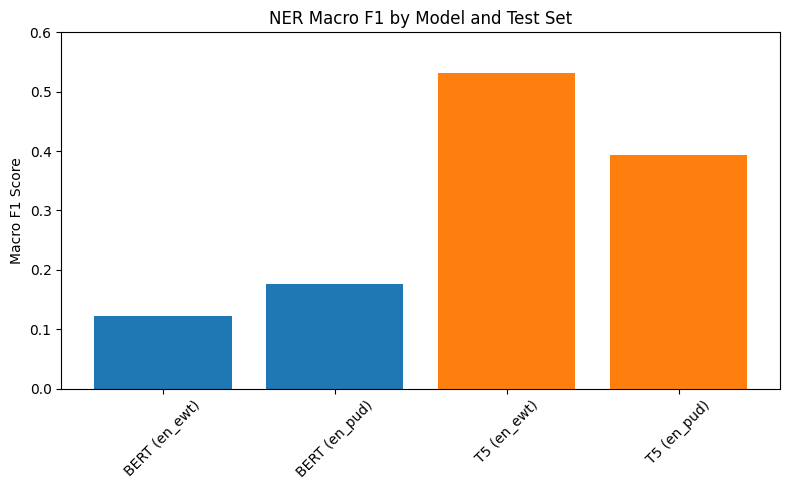

In [36]:
# Model Performance Comparison Plot

import matplotlib.pyplot as plt
import pandas as pd

# Performance summary
df = pd.DataFrame({
    "Model": ["BERT", "BERT", "T5", "T5"],
    "Test Set": ["en_ewt", "en_pud", "en_ewt", "en_pud"],
    "Macro F1": [0.1226, 0.1757, 0.5316, 0.3940]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(df["Model"] + " (" + df["Test Set"] + ")", df["Macro F1"], color=["#1f77b4", "#1f77b4", "#ff7f0e", "#ff7f0e"])
plt.ylabel("Macro F1 Score")
plt.title("NER Macro F1 by Model and Test Set")
plt.xticks(rotation=45)
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()


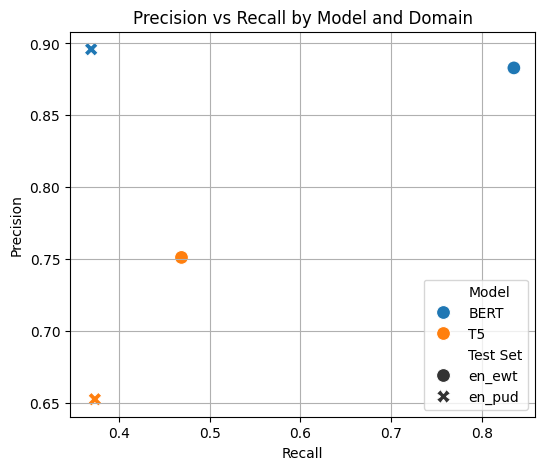

In [37]:
# Precision vs Recall Scatter Plot

import seaborn as sns

# Data
performance = {
    "Model": ["BERT", "BERT", "T5", "T5"],
    "Test Set": ["en_ewt", "en_pud", "en_ewt", "en_pud"],
    "Precision": [0.8830, 0.8960, 0.7512, 0.6526],
    "Recall": [0.8356, 0.3690, 0.4687, 0.3731]
}

df_perf = pd.DataFrame(performance)

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_perf, x="Recall", y="Precision", hue="Model", style="Test Set", s=100)
plt.title("Precision vs Recall by Model and Domain")
plt.grid(True)
plt.show()


In [43]:
# === Build & export: Main results, Boundary/Type, Length & Rarity slices, Δ figure ===
# Paste this cell at the END of your notebook and run it once.

import os, math
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# -------------------- Setup & directories --------------------
os.makedirs("results", exist_ok=True)
os.makedirs("exports", exist_ok=True)

assert "data_dict" in globals(), "data_dict not found (must contain en_ewt/en_pud)."
assert "tag2id"   in globals(), "tag2id (BIO tag -> int) must exist."
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = -100

# id2tag from tag2id if missing
if "id2tag" not in globals():
    id2tag = {v: k for k, v in tag2id.items()}

# -------------------- (Fallback) NERDataset if missing --------------------
if "NERDataset" not in globals():
    from torch.utils.data import Dataset
    from transformers import BertTokenizerFast

    class NERDataset(Dataset):
        def __init__(self, data, tag2id, tokenizer=None, max_length=128, label_all_subtokens=False):
            self.data = data
            self.tag2id = tag2id
            self.max_length = max_length
            self.label_all_subtokens = label_all_subtokens
            self.tokenizer = tokenizer or BertTokenizerFast.from_pretrained("bert-base-cased")

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            tokens, labels = self.data[idx]
            enc = self.tokenizer(
                tokens, is_split_into_words=True, truncation=True, padding="max_length",
                max_length=self.max_length, return_attention_mask=True, return_offsets_mapping=True
            )
            word_ids = enc.word_ids()
            aligned = []
            prev = None
            for wid in word_ids:
                if wid is None:
                    aligned.append(IGNORE_INDEX)
                elif wid != prev:
                    aligned.append(self.tag2id[labels[wid]])
                else:
                    # mask subword pieces (set label_all_subtokens=True to propagate I-*)
                    aligned.append(IGNORE_INDEX)
                prev = wid
            enc.pop("offset_mapping")
            enc["labels"] = aligned
            return {k: torch.tensor(v) for k, v in enc.items()}

# -------------------- Helper: BIO -> spans --------------------
def _bio_to_spans(seq: List[str]):
    spans = set()
    start, cur = None, None
    for i, tag in enumerate(list(seq) + ["O"]):
        if tag == "O":
            if cur is not None:
                spans.add((start, i - 1, cur))
                start, cur = None, None
            continue
        pref, typ = tag.split("-", 1) if "-" in tag else ("I", tag)
        if pref == "B" or (cur is not None and typ != cur):
            if cur is not None:
                spans.add((start, i - 1, cur))
            start, cur = i, typ
        elif cur is None:
            start, cur = i, typ
    return spans

def _spans_unlabelled(spans):
    return {(s, e) for (s, e, _) in spans}

# -------------------- Metrics --------------------
from sklearn.metrics import precision_recall_fscore_support

def micro_f1_labelled(gold_seqs: List[List[str]], pred_seqs: List[List[str]]):
    tp = fp = fn = 0
    for g, p in zip(gold_seqs, pred_seqs):
        G = _bio_to_spans(g); P = _bio_to_spans(p)
        tp += len(G & P); fp += len(P - G); fn += len(G - P)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return f1, prec, rec

def micro_f1_unlabelled(gold_seqs: List[List[str]], pred_seqs: List[List[str]]):
    tp = fp = fn = 0
    for g, p in zip(gold_seqs, pred_seqs):
        Gu = _spans_unlabelled(_bio_to_spans(g))
        Pu = _spans_unlabelled(_bio_to_spans(p))
        tp += len(Gu & Pu); fp += len(Pu - Gu); fn += len(Gu - Pu)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return f1, prec, rec

def token_macro_f1_exO(gold_seqs: List[List[str]], pred_seqs: List[List[str]]):
    gold = []; pred = []
    for g, p in zip(gold_seqs, pred_seqs):
        L = min(len(g), len(p))
        gold.extend(g[:L]); pred.extend(p[:L])
    labels = sorted((set(gold) | set(pred)) - {"O"})
    if not labels:
        return 0.0, 0.0, 0.0
    prec, rec, f1, _ = precision_recall_fscore_support(
        gold, pred, labels=labels, average="macro", zero_division=0
    )
    return float(f1), float(prec), float(rec)

# -------------------- Ensure BERT model & loaders --------------------
from transformers import BertTokenizerFast, BertForTokenClassification
from torch.utils.data import DataLoader

def _resolve_bert_model():
    m = None
    if "bert_model" in globals() and isinstance(bert_model, BertForTokenClassification):
        m = bert_model
    elif "model" in globals() and isinstance(model, BertForTokenClassification):
        m = model
    else:
        # fresh model; try to load best_state if available
        m = BertForTokenClassification.from_pretrained("bert-base-cased", num_labels=len(tag2id)).to(device)
        if "best_state" in globals() and isinstance(best_state, dict):
            try:
                m.load_state_dict(best_state, strict=False)
                print("Loaded best_state into a fresh BERT model.")
            except Exception as e:
                print("Warning: could not load best_state:", e)
    return m

def _ensure_loaders():
    need_build = ("test_loader" not in globals()) or ("ood_loader" not in globals())
    if not need_build:
        return globals()["test_loader"], globals()["ood_loader"]
    tok = BertTokenizerFast.from_pretrained("bert-base-cased")
    test_ds = NERDataset(data_dict["en_ewt"]["test"], tag2id, tokenizer=tok, max_length=128)
    ood_ds  = NERDataset(data_dict["en_pud"]["test"], tag2id, tokenizer=tok, max_length=128)
    tl = DataLoader(test_ds, batch_size=16, shuffle=False)
    ol = DataLoader(ood_ds,  batch_size=16, shuffle=False)
    globals()["test_loader"] = tl
    globals()["ood_loader"]  = ol
    return tl, ol

def _bert_sequences_fallback(m, loader, id2tag, device):
    m.eval(); out_gold, out_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = m(input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"])
            logits = out.logits
            preds = logits.argmax(-1).detach().cpu().numpy()
            golds = batch["labels"].detach().cpu().numpy()
            mask  = batch["attention_mask"].detach().cpu().numpy()
            for p, g, msk in zip(preds, golds, mask):
                gs, ps = [], []
                for pi, gi, mi in zip(p, g, msk):
                    if mi == 1 and gi != IGNORE_INDEX:
                        gs.append(id2tag[int(gi)])
                        ps.append(id2tag[int(pi)])
                out_gold.append(gs); out_pred.append(ps)
    return out_gold, out_pred

def get_bert_sequences(split: str):
    tl, ol = _ensure_loaders()
    m = _resolve_bert_model()
    loader = tl if split.upper() == "EWT" else ol
    if "bert_sequences" in globals():
        return bert_sequences(m, loader, id2tag, device)
    return _bert_sequences_fallback(m, loader, id2tag, device)

# -------------------- T5 sequences (safe resolver) --------------------
from transformers import T5Tokenizer, T5ForConditionalGeneration

def _resolve_t5_tok_and_model():
    # tokenizer
    try:
        t5_tok = tokenizer if isinstance(tokenizer, T5Tokenizer) else T5Tokenizer.from_pretrained("t5-small")
    except NameError:
        t5_tok = T5Tokenizer.from_pretrained("t5-small")
    # model
    t5_m = None
    if "trainer" in globals() and hasattr(trainer, "model") and isinstance(trainer.model, T5ForConditionalGeneration):
        t5_m = trainer.model
    elif "t5_model" in globals() and isinstance(t5_model, T5ForConditionalGeneration):
        t5_m = t5_model
    elif "model" in globals() and isinstance(model, T5ForConditionalGeneration):
        t5_m = model
    elif "model" in globals() and isinstance(model, str) and model.lower().startswith("t5"):
        t5_m = T5ForConditionalGeneration.from_pretrained(model).to(device)
    if t5_m is None:
        t5_m = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
    return t5_tok, t5_m

def _pairs_ok(pairs):
    return [(t, y) for (t, y) in pairs if len(t) == len(y) and len(t) > 0]

@torch.no_grad()
def t5_sequences_from_pairs(pairs, valid_tags=None, src_maxlen=128, tgt_maxlen=64, batch_size=16):
    t5_tok, t5_m = _resolve_t5_tok_and_model()
    if valid_tags is None:
        valid_tags = set(tag2id.keys())
    gold_all, pred_all = [], []
    for i in range(0, len(pairs), batch_size):
        chunk = pairs[i:i+batch_size]
        inputs = [" ".join(toks) for toks, _ in chunk]
        golds  = [" ".join(tags) for _, tags in chunk]
        enc = t5_tok(inputs, max_length=src_maxlen, truncation=True, padding=True, return_tensors="pt").to(device)
        gen = t5_m.generate(**enc, max_length=tgt_maxlen)
        preds = [t5_tok.decode(o, skip_special_tokens=True).split() for o in gen]
        golds = [g.split() for g in golds]
        for g, p in zip(golds, preds):
            # sanitize to valid tags and align lengths
            p = [w if w in valid_tags else "O" for w in p]
            if len(p) < len(g): p = p + ["O"] * (len(g) - len(p))
            elif len(p) > len(g): p = p[:len(g)]
            gold_all.append(g); pred_all.append(p)
    return gold_all, pred_all

def get_t5_sequences(split: str, src_maxlen=128, tgt_maxlen=64):
    if split.upper() == "EWT":
        pairs = _pairs_ok(data_dict["en_ewt"]["test"])
    else:
        pairs = _pairs_ok(data_dict["en_pud"]["test"])
    valid = set(tag2id.keys())
    return t5_sequences_from_pairs(pairs, valid_tags=valid, src_maxlen=src_maxlen, tgt_maxlen=tgt_maxlen)

# -------------------- Robust table-to-PDF helper (auto widths) --------------------
def _table_pdf(pdf_path, df, headers, col_widths=None, figsize=(7.8, 2.4), fontsize=10.5, scale=(1.05,1.35)):
    from matplotlib.backends.backend_pdf import PdfPages
    # auto-fix widths if missing / mismatched
    if (col_widths is None) or (len(col_widths) != len(headers)):
        col_widths = [1.0 / len(headers)] * len(headers)
    with PdfPages(pdf_path) as pdf:
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis('off')
        tbl = ax.table(cellText=df.values,
                       colLabels=headers,
                       colLoc='center', cellLoc='center',
                       colWidths=col_widths,
                       loc='center', edges='closed')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(fontsize)
        tbl.scale(*scale)
        for (r,c), cell in tbl.get_celld().items():
            if r == 0:
                cell.set_text_props(weight='bold')
            else:
                if c in (0,1):  # left-align first two columns when present
                    cell.get_text().set_horizontalalignment('left')
        pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

# -------------------- Main Results (Table 1) --------------------
def _collect_main(model_name: str, split: str, gold_seqs, pred_seqs):
    t_f1, _, _    = token_macro_f1_exO(gold_seqs, pred_seqs)
    s_lbl, _, _   = micro_f1_labelled(gold_seqs, pred_seqs)
    s_unl, _, _   = micro_f1_unlabelled(gold_seqs, pred_seqs)
    return {"Model": model_name, "Split": split,
            "TokenMacroF1_exO": t_f1, "SpanF1_labelled": s_lbl, "SpanF1_unlabelled": s_unl}

print("Computing main results (may take a bit for T5 generation)...")
bert_gold_ewt, bert_pred_ewt = get_bert_sequences("EWT")
bert_gold_pud, bert_pred_pud = get_bert_sequences("PUD")
t5_gold_ewt,  t5_pred_ewt    = get_t5_sequences("EWT", src_maxlen=globals().get("SOURCE_MAXLEN",128), tgt_maxlen=globals().get("TARGET_MAXLEN",64))
t5_gold_pud,  t5_pred_pud    = get_t5_sequences("PUD", src_maxlen=globals().get("SOURCE_MAXLEN",128), tgt_maxlen=globals().get("TARGET_MAXLEN",64))

rows = [
    _collect_main("BERT", "EWT", bert_gold_ewt, bert_pred_ewt),
    _collect_main("BERT", "PUD", bert_gold_pud, bert_pred_pud),
    _collect_main("T5",   "EWT", t5_gold_ewt,  t5_pred_ewt),
    _collect_main("T5",   "PUD", t5_gold_pud,  t5_pred_pud),
]
df_main = pd.DataFrame(rows)
display(df_main.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x))
df_main.to_csv("results/MainResults.csv", index=False)
print("Saved:", "results/MainResults.csv")

# Export Table 1 as table-only PDF
t1 = df_main.copy()
for col in ["TokenMacroF1_exO","SpanF1_labelled","SpanF1_unlabelled"]:
    t1[col] = t1[col].map(lambda x: f"{x:.4f}")
t1 = t1[["Model","Split","TokenMacroF1_exO","SpanF1_labelled","SpanF1_unlabelled"]]
_table_pdf("exports/Table1_main_only.pdf", t1,
           headers=["Model","Split","Token macro-F1 (ex-O)","Span-F1 (labelled)","Span-F1 (unlabelled)"])
print("Saved:", "exports/Table1_main_only.pdf")

# -------------------- Boundary vs Type (Table 2) --------------------
def boundary_type_breakdown_table(gold_seqs, pred_seqs):
    lab_correct = type_wrong = b_missed = b_spurious = 0
    total_gold = total_pred = 0
    for g, p in zip(gold_seqs, pred_seqs):
        G = _bio_to_spans(g); P = _bio_to_spans(p)
        Gu = _spans_unlabelled(G); Pu = _spans_unlabelled(P)
        total_gold += len(G); total_pred += len(P)
        lab_correct += len(G & P)
        # type wrong given same boundary
        for (s,e) in (Gu & Pu):
            gt = [t for (sg,eg,t) in G if sg==s and eg==e][0]
            pt = [t for (sp,ep,t) in P if sp==s and ep==e][0]
            if gt != pt: type_wrong += 1
        b_missed   += len(Gu - Pu)
        b_spurious += len(Pu - Gu)
    return {
        "labelled_correct": lab_correct,
        "type_wrong_at_boundary": type_wrong,
        "boundary_missed": b_missed,
        "boundary_spurious": b_spurious,
        "gold_total": total_gold,
        "pred_total": total_pred,
    }

def _bt_row(model_name, split, gold, pred):
    d = boundary_type_breakdown_table(gold, pred)
    miss_rate = d["boundary_missed"]/max(1,d["gold_total"])
    spur_rate = d["boundary_spurious"]/max(1,d["pred_total"])
    type_rate = d["type_wrong_at_boundary"]/max(1,(d["labelled_correct"]+d["type_wrong_at_boundary"]))
    return {
        "Model": model_name, "Split": split,
        "Labelled correct": d["labelled_correct"],
        "Type wrong @ boundary": d["type_wrong_at_boundary"],
        "Boundary missed": d["boundary_missed"],
        "Boundary spurious": d["boundary_spurious"],
        "Type error | boundary": type_rate,
        "Miss rate (Gold)": miss_rate,
        "Spurious rate (Pred)": spur_rate
    }

df_bt = pd.DataFrame([
    _bt_row("BERT","EWT", bert_gold_ewt, bert_pred_ewt),
    _bt_row("BERT","PUD", bert_gold_pud, bert_pred_pud),
    _bt_row("T5","EWT",   t5_gold_ewt,  t5_pred_ewt),
    _bt_row("T5","PUD",   t5_gold_pud,  t5_pred_pud),
])
df_bt.to_csv("results/boundary_type_proxy.csv", index=False)

bt_disp = df_bt.copy()
for c in ["Type error | boundary","Miss rate (Gold)","Spurious rate (Pred)"]:
    bt_disp[c] = bt_disp[c].map(lambda x: f"{x:.3f}")
_table_pdf("exports/Table2_BoundaryType_Proxy_only.pdf", bt_disp,
           headers=list(bt_disp.columns))  # auto widths
print("Saved:", "results/boundary_type_proxy.csv")
print("Saved:", "exports/Table2_BoundaryType_Proxy_only.pdf")

# -------------------- Length slices (Table 3) --------------------
def _length_bucket(s,e):
    L = (e - s + 1)
    if L == 1: return "1"
    if 2 <= L <= 3: return "2–3"
    return "≥4"

def span_f1_by_length_table(gold_seqs, pred_seqs):
    buckets = {"1":[], "2–3":[], "≥4":[]}
    counts = {k: {"tp":0,"fp":0,"fn":0} for k in buckets}
    for g,p in zip(gold_seqs, pred_seqs):
        G = _bio_to_spans(g); P = _bio_to_spans(p)
        for b in buckets:
            G_b = {x for x in G if _length_bucket(x[0],x[1]) == b}
            P_b = {x for x in P if _length_bucket(x[0],x[1]) == b}
            counts[b]["tp"] += len(G_b & P_b)
            counts[b]["fp"] += len(P_b - G_b)
            counts[b]["fn"] += len(G_b - P_b)
    rows = []
    for b in ["1","2–3","≥4"]:
        tp,fp,fn = counts[b]["tp"],counts[b]["fp"],counts[b]["fn"]
        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        rows.append({"Bucket": b, "SpanF1_labelled": f1, "Precision": prec, "Recall": rec})
    return pd.DataFrame(rows)

len_tbl_bert_ewt = span_f1_by_length_table(bert_gold_ewt, bert_pred_ewt)
len_tbl_bert_pud = span_f1_by_length_table(bert_gold_pud, bert_pred_pud)
len_tbl_t5_ewt   = span_f1_by_length_table(t5_gold_ewt,  t5_pred_ewt)
len_tbl_t5_pud   = span_f1_by_length_table(t5_gold_pud,  t5_pred_pud)

len_tbl_bert_ewt.to_csv("results/length_slices_bert_ewt.csv", index=False)
len_tbl_bert_pud.to_csv("results/length_slices_bert_pud.csv", index=False)
len_tbl_t5_ewt.to_csv("results/length_slices_t5_ewt.csv", index=False)
len_tbl_t5_pud.to_csv("results/length_slices_t5_pud.csv", index=False)
print("Saved length slice CSVs in results/")

len_all = pd.concat([
    len_tbl_bert_ewt.assign(Model="BERT", Split="EWT"),
    len_tbl_bert_pud.assign(Model="BERT", Split="PUD"),
    len_tbl_t5_ewt.assign(Model="T5", Split="EWT"),
    len_tbl_t5_pud.assign(Model="T5", Split="PUD"),
], ignore_index=True)
len_disp = len_all.copy()
for c in ["SpanF1_labelled","Precision","Recall"]:
    len_disp[c] = len_disp[c].map(lambda x: f"{x:.4f}")
len_disp = len_disp[["Model","Split","Bucket","SpanF1_labelled","Precision","Recall"]]
_table_pdf("exports/LengthSlices_table.pdf", len_disp,
           headers=list(len_disp.columns))  # auto widths
print("Saved:", "exports/LengthSlices_table.pdf")

# -------------------- Rarity slices (Table 4) --------------------
def build_surface_freq(train_pairs):
    from collections import Counter
    cnt = Counter()
    for toks, tags in train_pairs:
        spans = _bio_to_spans(tags)
        for (s,e,_) in spans:
            surf = " ".join(toks[s:e+1]).lower()
            cnt[surf] += 1
    return cnt

def quantile_buckets_from_freq(freq_counter):
    vals = np.array(list(freq_counter.values()))
    if len(vals) == 0:
        return {"head": set(), "mid": set(), "tail": set()}
    q33, q66 = np.quantile(vals, [0.33, 0.66])
    head = {k for k,v in freq_counter.items() if v > q66}
    tail = {k for k,v in freq_counter.items() if v <= q33}
    mid  = set(freq_counter.keys()) - head - tail
    return {"head": head, "mid": mid, "tail": tail}

def span_f1_by_rarity_table(test_pairs, pred_seqs, freq_buckets):
    rows = []
    gold_seqs = [tags for _, tags in test_pairs]
    tokens_l  = [toks for toks, _ in test_pairs]
    for bucket in ["head","mid","tail"]:
        tp=fp=fn=0
        for toks, gold_tags, pred_tags in zip(tokens_l, gold_seqs, pred_seqs):
            G = _bio_to_spans(gold_tags); P = _bio_to_spans(pred_tags)
            G_b = {(s,e,t) for (s,e,t) in G if " ".join(toks[s:e+1]).lower() in freq_buckets[bucket]}
            P_b = {(s,e,t) for (s,e,t) in P if " ".join(toks[s:e+1]).lower() in freq_buckets[bucket]}
            tp += len(G_b & P_b); fp += len(P_b - G_b); fn += len(G_b - P_b)
        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        rows.append({"Bucket": bucket, "SpanF1_labelled": f1, "Precision": prec, "Recall": rec})
    return pd.DataFrame(rows)

ewt_train_pairs = _pairs_ok(data_dict["en_ewt"]["train"])
train_freq = build_surface_freq(ewt_train_pairs)
buckets = quantile_buckets_from_freq(train_freq)

ewt_test_pairs = _pairs_ok(data_dict["en_ewt"]["test"])
pud_test_pairs = _pairs_ok(data_dict["en_pud"]["test"])

rar_bert_ewt = span_f1_by_rarity_table(ewt_test_pairs, bert_pred_ewt, buckets)
rar_bert_pud = span_f1_by_rarity_table(pud_test_pairs, bert_pred_pud, buckets)
rar_t5_ewt   = span_f1_by_rarity_table(ewt_test_pairs, t5_pred_ewt,  buckets)
rar_t5_pud   = span_f1_by_rarity_table(pud_test_pairs, t5_pred_pud,  buckets)

rar_bert_ewt.to_csv("results/rarity_slices_bert_ewt.csv", index=False)
rar_bert_pud.to_csv("results/rarity_slices_bert_pud.csv", index=False)
rar_t5_ewt.to_csv("results/rarity_slices_t5_ewt.csv", index=False)
rar_t5_pud.to_csv("results/rarity_slices_t5_pud.csv", index=False)
print("Saved rarity slice CSVs in results/")

rar_all = pd.concat([
    rar_bert_ewt.assign(Model="BERT", Split="EWT"),
    rar_bert_pud.assign(Model="BERT", Split="PUD"),
    rar_t5_ewt.assign(Model="T5", Split="EWT"),
    rar_t5_pud.assign(Model="T5", Split="PUD"),
], ignore_index=True)
rar_disp = rar_all.copy()
for c in ["SpanF1_labelled","Precision","Recall"]:
    rar_disp[c] = rar_disp[c].map(lambda x: f"{x:.4f}")
rar_disp = rar_disp[["Model","Split","Bucket","SpanF1_labelled","Precision","Recall"]]
_table_pdf("exports/RaritySlices_table.pdf", rar_disp,
           headers=list(rar_disp.columns))  # auto widths
print("Saved:", "exports/RaritySlices_table.pdf")

# -------------------- Optional Δ figure (BERT − T5, labelled span-F1) --------------------
pivot = df_main.pivot(index="Split", columns="Model", values="SpanF1_labelled")
delta_ewt = float(pivot.loc["EWT","BERT"] - pivot.loc["EWT","T5"])
delta_pud = float(pivot.loc["PUD","BERT"] - pivot.loc["PUD","T5"])

fig = plt.figure(figsize=(4.8,3.2))
ax = plt.gca()
ax.bar(["EWT","PUD"], [delta_ewt, delta_pud])
ax.set_ylabel("Δ span-F1 (BERT − T5)")
# Robust y-limits for negatives/positives
ymin = min(0.0, delta_ewt, delta_pud) * 1.15
ymax = max(0.0, delta_ewt, delta_pud) * 1.15 if max(delta_ewt, delta_pud) != 0 else 0.01
ax.set_ylim(ymin, ymax if ymax > ymin else ymin + 0.02)
ax.axhline(0.0, color='black', linewidth=0.8)
for i, v in enumerate([delta_ewt, delta_pud]):
    offset = 0.01 if v >= 0 else -0.03
    ax.text(i, v + offset, f"{v:.3f}", ha="center", va="bottom" if v>=0 else "top")
fig.tight_layout()
fig_path = "exports/Fig_delta_point_estimates.png"
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("Saved:", fig_path)


Computing main results (may take a bit for T5 generation)...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded best_state into a fresh BERT model.


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded best_state into a fresh BERT model.


/tmp/ipython-input-1704351835.py:286: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(df_main.applymap(lambda x: f"{x:.4f}" if isinstance(x, float) else x))


,Model,Split,TokenMacroF1_exO,SpanF1_labelled,SpanF1_unlabelled
0,BERT,EWT,0.7841,0.8152,0.8517
1,BERT,PUD,0.8104,0.8037,0.8729
2,T5,EWT,0.2100,0.2532,0.2644
3,T5,PUD,0.1044,0.1098,0.1227


Saved: results/MainResults.csv
Saved: exports/Table1_main_only.pdf
Saved: results/boundary_type_proxy.csv
Saved: exports/Table2_BoundaryType_Proxy_only.pdf
Saved length slice CSVs in results/
Saved: exports/LengthSlices_table.pdf
Saved rarity slice CSVs in results/
Saved: exports/RaritySlices_table.pdf
Saved: exports/Fig_delta_point_estimates.png
